# Import libraries

In [1]:
# import key libraries and kernel settings
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols, mixedlm
import time
from datetime import date
import matplotlib.lines as mlines

# updated src file changes are loaded
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath(".."))

# Load data

In [2]:
from src.loading import load_data # function to import columns without NAs, dropping columns with NAs (unless specified as a 'keep_col')

# -------------------- 3.0 m/s water current data
df_3 = load_data("../data/target_trial_3.parquet")
# ------------------- 2.0 m/s water current data
df_2 = load_data("../data/target_trial_2.parquet")

# combine dfs
df_full = pd.concat([df_2, df_3], ignore_index=True)

In [5]:
print(len(np.unique(df_3['ppid'])))
print(np.unique(df_3['ppid']))
df_3.groupby('set_order', observed=True)['ppid'].nunique()

45
['1' 'p002' 'p003' 'p004' 'p005' 'p006' 'p007' 'p009' 'p010' 'p011' 'p014'
 'p015' 'p016' 'p017' 'p018' 'p019' 'p020' 'p021' 'p023' 'p025' 'p026'
 'p027' 'p028' 'p029' 'p030' 'p031' 'p032' 'p033' 'p034' 'p035' 'p036'
 'p037' 'p038' 'p039' 'p040' 'p041' 'p042' 'p043' 'p044' 'p045' 'p046'
 'p047' 'p048' 'p049' 'p050']


set_order
1    20
2    25
Name: ppid, dtype: int64

In [7]:
print(len(np.unique(df_2['ppid'])))
print(np.unique(df_2['ppid']))
df_2.groupby('set_order', observed=True)['ppid'].nunique()

43
['p000' 'p002' 'p003' 'p004' 'p005' 'p006' 'p007' 'p008' 'p009' 'p010'
 'p011' 'p012' 'p013' 'p014' 'p015' 'p016' 'p017' 'p018' 'p021' 'p022'
 'p023' 'p024' 'p026' 'p028' 'p029j' 'p030' 'p031' 'p032' 'p033' 'p034'
 'p035' 'p036' 'p037' 'p042' 'p043' 'p044' 'p045' 'p046' 'p047' 'p048'
 'p049' 'p050' 'p051']


set_order
1    21
2    22
Name: ppid, dtype: int64

# Format df

In [5]:

# add new variables
df_full['lateral_error_x'] = (df_full['min_pos_from_target_x'] - df_full['target_position_x']) 
df_full['depth_error_z'] = (df_full['min_pos_from_target_z'] - df_full['target_position_z']) 

# convert key columns to cm:
from src.convert_to_cm import convert_to_cm # function to convert listed columns into cm

df_labeled = convert_to_cm(df_full,
              cols=[
                    'min_pos_from_target_x',
                    'min_pos_from_target_z',
                    'target_position_x',
                    'target_position_z',
                    'lateral_error_x',
                    'depth_error_z'
                   ])

print('res:', df_labeled['target_position_x'].dtypes) # check

# label ppid by water speed
from src.label_water_speed_ppid import label_water_condtion_ppid 
# function that labels ppid data by the speed condition (i.e., 2.0 or 3.0 m/s) and creates a new ppid_full column
df_labeled = label_water_condtion_ppid(df_labeled, ppid_col='ppid', water_col='water_speed_m_s', selected_speeds=[-3.0,-2.0,0.0]).copy() 


df_labeled['launch_deviation'] = (df_labeled['launch_deviation'] * -1.0).copy()
print(df_labeled['launch_deviation'])

# adjust target label with more readable labels
target_mapping = {
    "p0.6": "R60",
    "p0.3": "R30",
    "neg0.3": "L30",
    "neg0.6": "L60"
}
df_labeled['target_x_label'] = df_labeled['target_x_label'].map(target_mapping).copy() # apply new labels

from src.features import order_targets # orders targets from most negative (L60/-60) to most positive (R60/+60) for plotting purposes
df_labeled['target_position_x'] = order_targets(df_labeled.copy())
df_labeled['target_x_label'] = order_targets(df_labeled.copy())

# signed euclidian distance
df_labeled['signed_euclidean_cm'] = (df_labeled['distance_from_target'] * 100) * np.sign(df_labeled['lateral_error_x_cm'])
print(df_labeled.groupby(['target_hit'])['signed_euclidean_cm'].min())
print(df_labeled.groupby(['target_hit'])['signed_euclidean_cm'].max())

# Generate a less ambiguous label for set_order reflecting the first target pair positions (left, first digit; right, second digit); underscore seperates the second pair
df_labeled['set_order'] = df_labeled['set_order'].cat.rename_categories({
    '1': '63_36',
    '2': '36_63'
}).copy()

# ensures PCA compatibility
df_labeled['water_speed_m_s'] = df_labeled['water_speed_m_s'].replace(0.0, 0.0001).copy()


# add temporal phase label categorical varible
from src.add_phases import label_phases, df_add_phases # function that makes new column representing the phnase of the task based on the upper and lower trial bounds
phases = label_phases() 

df_labeled = df_add_phases(df_labeled, phase_array=phases).copy()

phase_order = [
    'familiarization',
    'baseline', 
    'training_1', 
    'washout_1', 
    'training_2', 
    'washout_2'
]

df_labeled['phase'] = pd.Categorical(
    df_labeled['phase'], 
    categories=phase_order, 
    ordered=True
)


from src.add_cycles import add_cycles # function that adds a cycle/block counter globally and per target
df_labeled = add_cycles(df_labeled,
                       n_trials=4,
                       ppid_col='ppid_full',
                       target_col='target_x_label',
                       ).copy()

# filter out familiarization (i.e, starts with an 'f')
df_nf = df_labeled[~df_labeled['phase'].str.startswith('f')].copy()

# remove trials that do not cross a certain threshold in the z-plane (i.e, trials that did not exceed 70 cm in the z-plane)
from src.cleaning import crossed_threshold # first exclusion criteria, drops 397 trials

# make column checking if ball crossed 70.0 cm on z axis
df_nf['crossed_threshold'] = df_nf.apply(
    lambda row: crossed_threshold(row, col="ball_pos_z", val=0.7), # 70 cm
        axis=1
).copy()

print(df_nf['crossed_threshold'].value_counts()) # check number of failed trials (397 total)


# Make a seperate df without trials that did not cross threshold
df_filt = df_nf[df_nf['crossed_threshold']].copy() # retains rows where crossed_threshold == True

# reduce df to key cols as we do not need all raw data output from Unity
from src.cleaning import extract_key_columns
df_small_filt = extract_key_columns(df_filt).copy()


print(df_small_filt.columns)

res: float64
0        12.833083
1         5.548219
2         5.863291
3        -0.443143
4         3.916917
           ...    
43640    -5.273447
43641     1.938383
43642     2.213391
43643    -3.030887
43644    15.191531
Name: launch_deviation, Length: 43645, dtype: float64
0        R30
1        R60
2        L60
3        L30
4        L30
        ... 
43640    R30
43641    R30
43642    L60
43643    R30
43644    L60
Name: target_x_label, Length: 43645, dtype: category
Categories (4, object): ['L60' < 'L30' < 'R30' < 'R60']
0        R30
1        R60
2        L60
3        L30
4        L30
        ... 
43640    R30
43641    R30
43642    L60
43643    R30
43644    L60
Name: target_x_label, Length: 43645, dtype: category
Categories (4, object): ['L60' < 'L30' < 'R30' < 'R60']
target_hit
False   -148.5813
True      -5.4465
Name: signed_euclidean_cm, dtype: float64
target_hit
False    148.5813
True       5.4019
Name: signed_euclidean_cm, dtype: float64
crossed_threshold
True     41480
False    

In [47]:
print(df_small_filt.groupby(['target_hit'])['ball_dist_to_center_cm'].agg(['min','max']))

                 min         max
target_hit                      
False       8.709477  207.145825
True        0.142103   17.460295


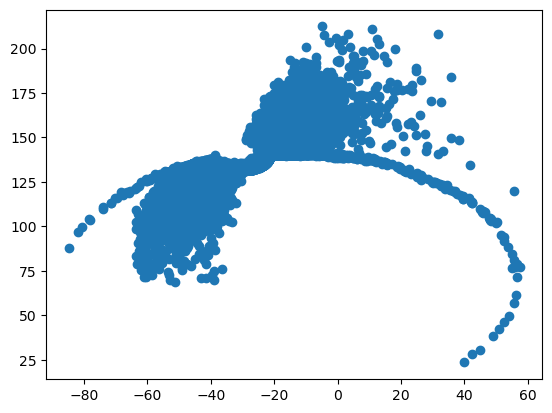

0.0011


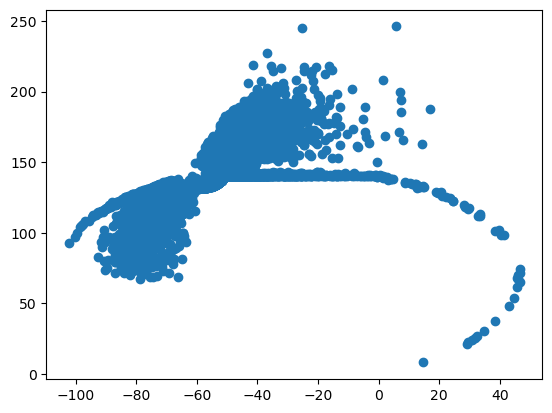

0.3929


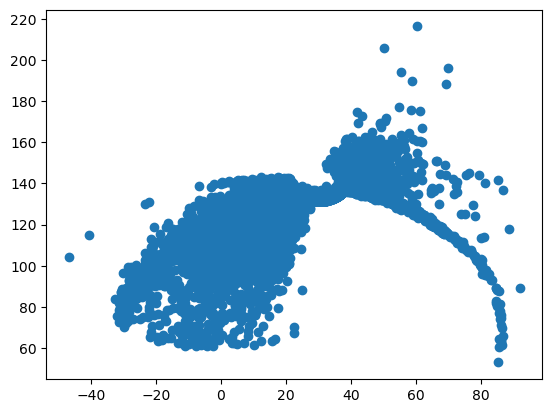

0.0031000000000000003


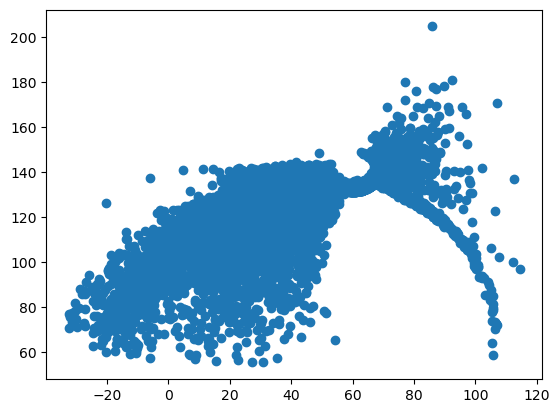

0.012899999999999998


In [14]:

for t in np.unique(df_small_filt['target_x_label']):

    df_subset = df_small_filt[df_small_filt['target_x_label'] == t]
    
    plt.scatter(df_subset['min_pos_from_target_x_cm'], df_subset['min_pos_from_target_z_cm'])
    plt.show()
    
    print(np.abs(df_subset['min_pos_from_target_x_cm']).min())

# Perturbation State Across Trials (0.0 = OFF / 1.0 = ON)

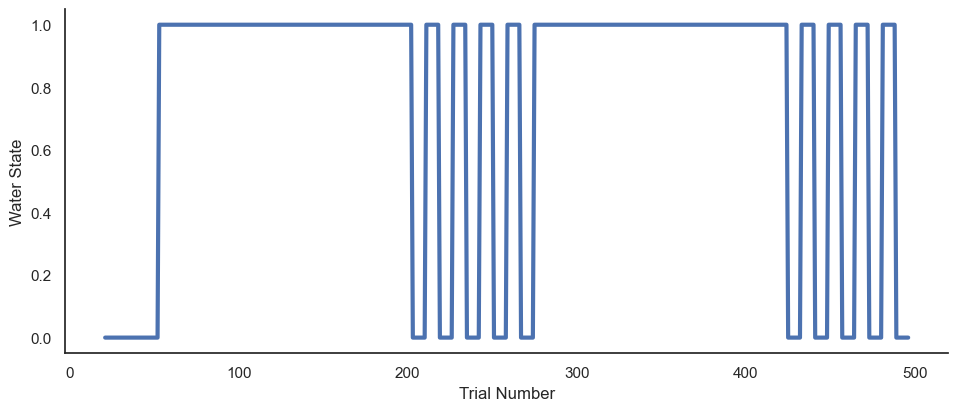

In [123]:
from src.plotting import plot_trial_schedule # function to show the changes in the water current across trials
# trial schedule plot
g = plot_trial_schedule(df_small_filt, context='notebook', font_scale=1, y_col='water_speed_binary')

In [11]:
print(df_small_filt.groupby(['phase'])['trial_num'].agg(['min','max']))

                   min    max
phase                        
familiarization    NaN    NaN
baseline          21.0   52.0
training_1        53.0  202.0
washout_1        203.0  274.0
training_2       275.0  424.0
washout_2        425.0  496.0


C:\Users\jacob\AppData\Local\Temp\ipykernel_10184\3411500277.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_small_filt.groupby(['phase'])['trial_num'].agg(['min','max']))


### **Virtual Environment Parameters**

| Parameter | Symbol | Value | Unit | Description |
| :--- | :---: | :--- | :--- | :--- |
| **Ball Mass** | $m$ | $1.0$ | $\text{kg}$ | Virtual mass of the projectile |
| **Water Density** | $\rho_w$ | $1000.0$ | $\text{kg/m}^3$ | Density of fluid medium |
| **Air Density** | $\rho_a$ | $1.225$ | $\text{kg/m}^3$ | Standard atmospheric density |
| **Drag Coefficient (Water)** | $C_{dw}$ | $0.47$ | - | Coefficient for a spherical object |
| **Drag Coefficient (Air)** | $C_{da}$ | $0.47$ | - | Coefficient for a spherical object |
| **Cross-sectional Area** | $A$ | $78.5398$ | $\text{cm}^2$ | Calculated as $\pi r^2$ ($r = 5.0 \text{ cm}$) |
| **Submersion Ratio** | - | $0.50$ | - | Portion of the ball subject to water drag |
| **Sampling Rate** | $\Delta t$ | $0.01389$ | $\text{s}$ | Physics update frequency ($72\text{ Hz}$) |

### **Lateral Force Calculation**

The water current force applied to the projectile was calculated based on the following equation, incorporating the $50\%$ submersion factor:

$$Waterforce = |S|^2 \frac{1}{2} C_{dw} \rho_w \left( \frac{A}{2} \right)$$

**Where:**
* **$|S|$**: The magnitude of the water speed ($2.0$ or $3.0$ m/s).
* **$C_{dw}$**: Water drag coefficient ($0.47$).
* **$\rho_w$**: Water density ($1000.0$ kg/m³).
* **$A$**: Total cross-sectional area of the ball.
* **$\frac{A}{2}$**: Effective area subject to drag (reflecting $50\%$ submersion).

# Ball Trajectory Data Across Workspace

In [12]:
# from src.extract_full_trajectories import trial_trajectory

# # in meters...

# trial_trajectory(df_small_filt,
#                  x_array='ball_pos_z',
#                  z_array='ball_pos_x',
#                  colour_col='ball_dist_to_center_cm', 
#                  water_col='water_speed_m_s'
#                 )


# Primary Axis of Error

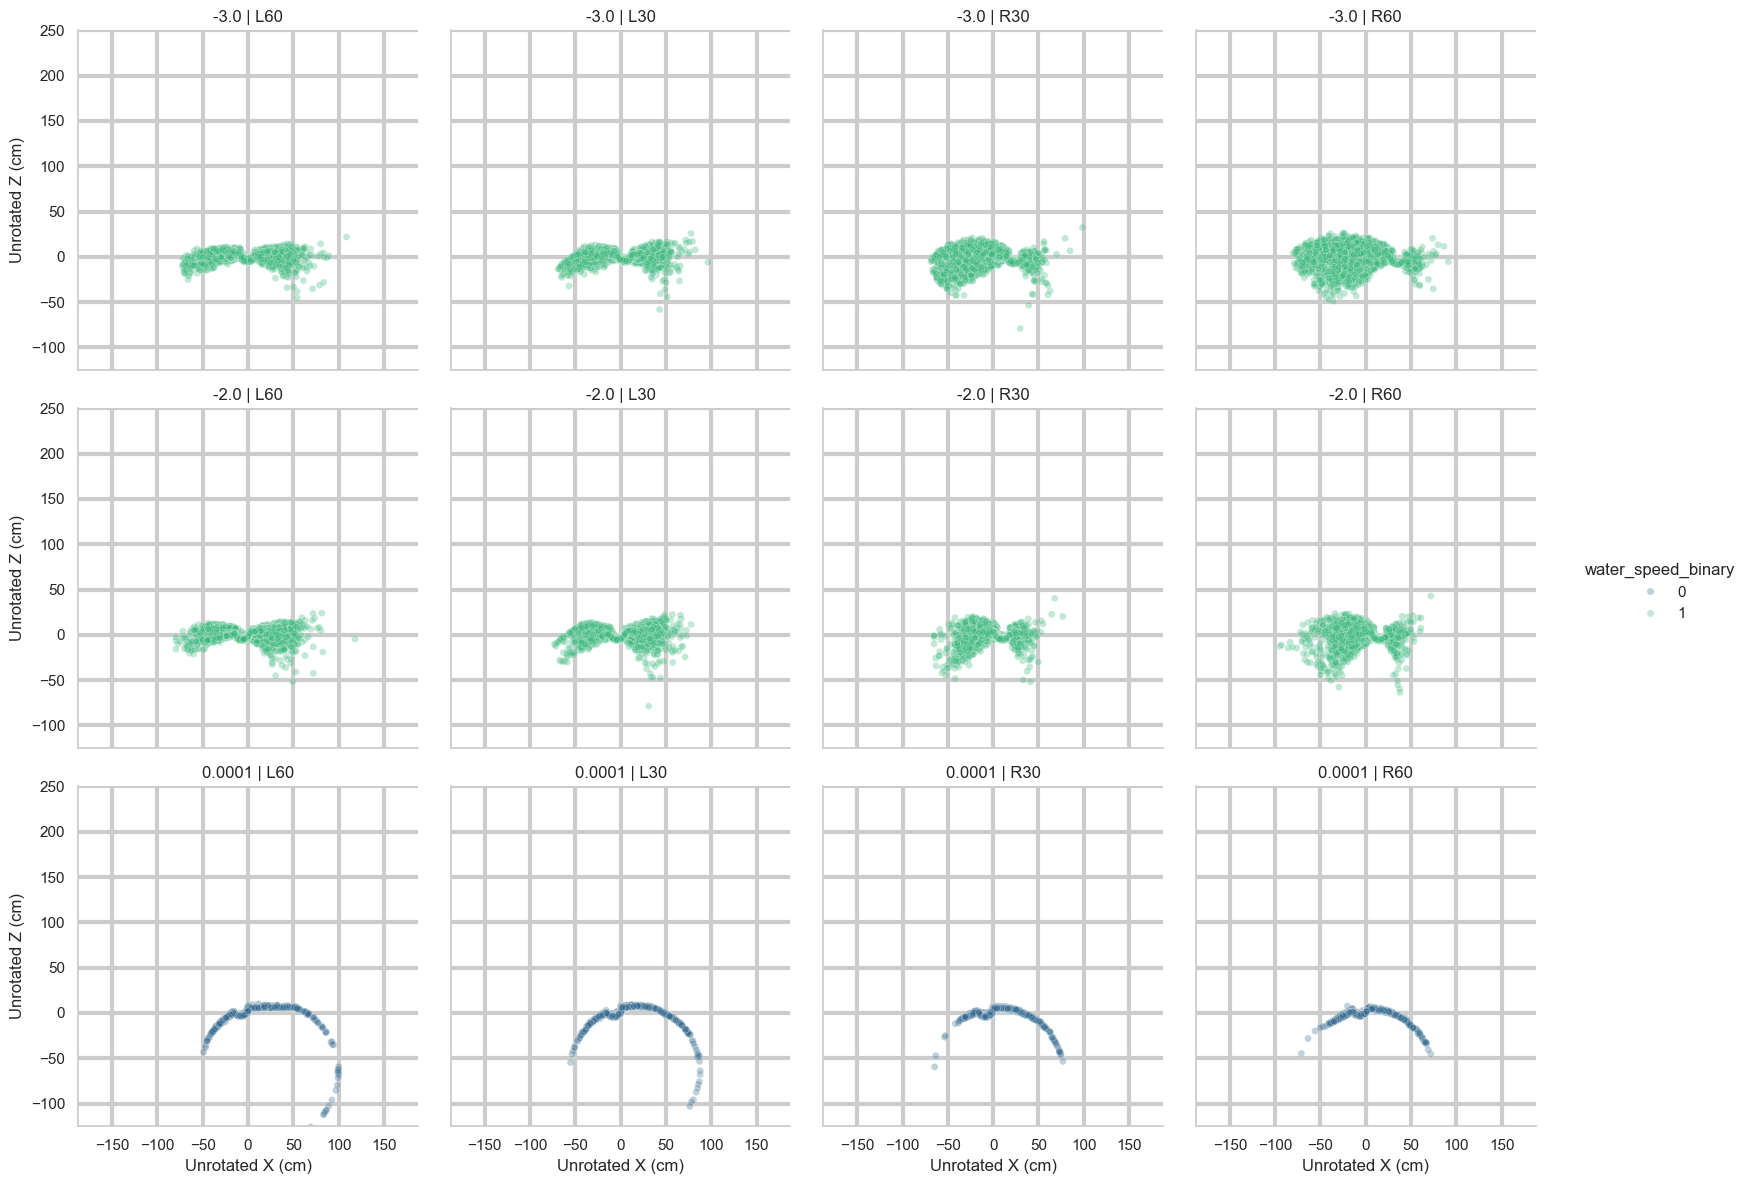

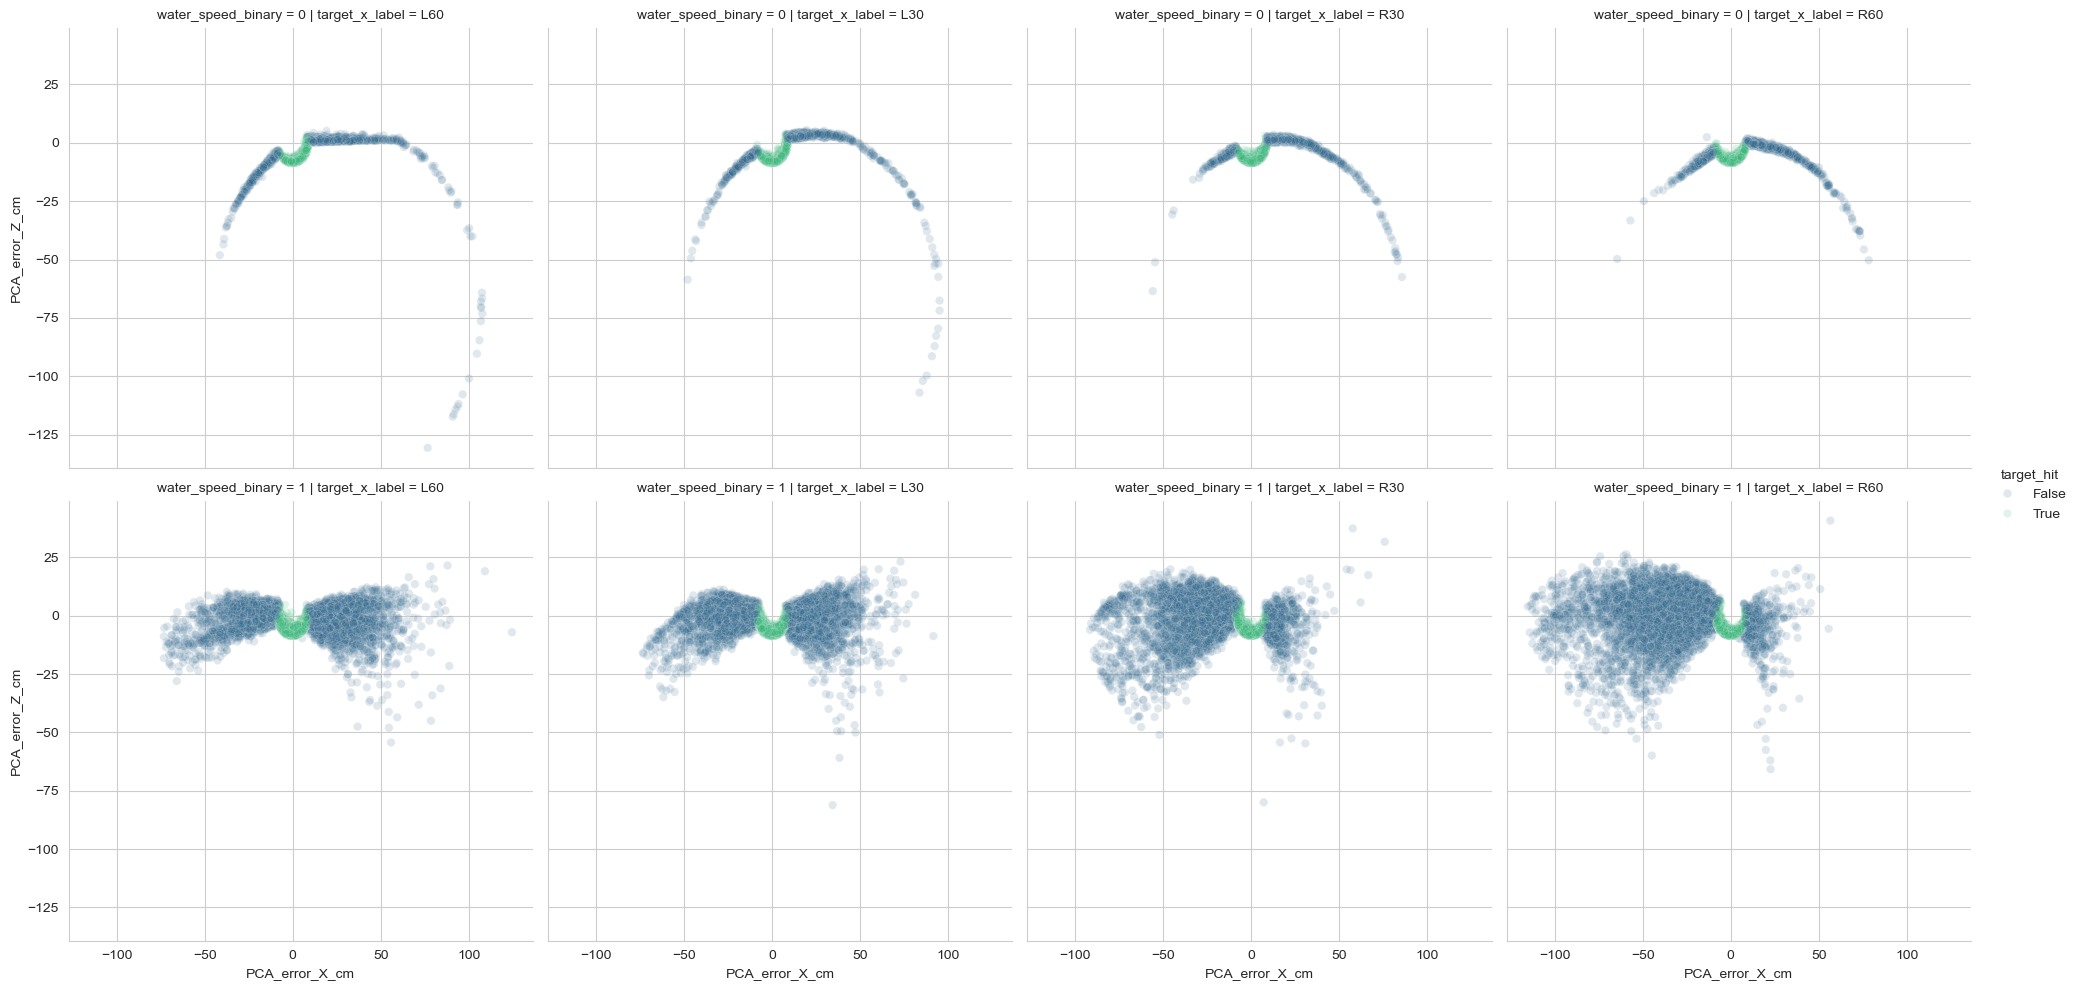

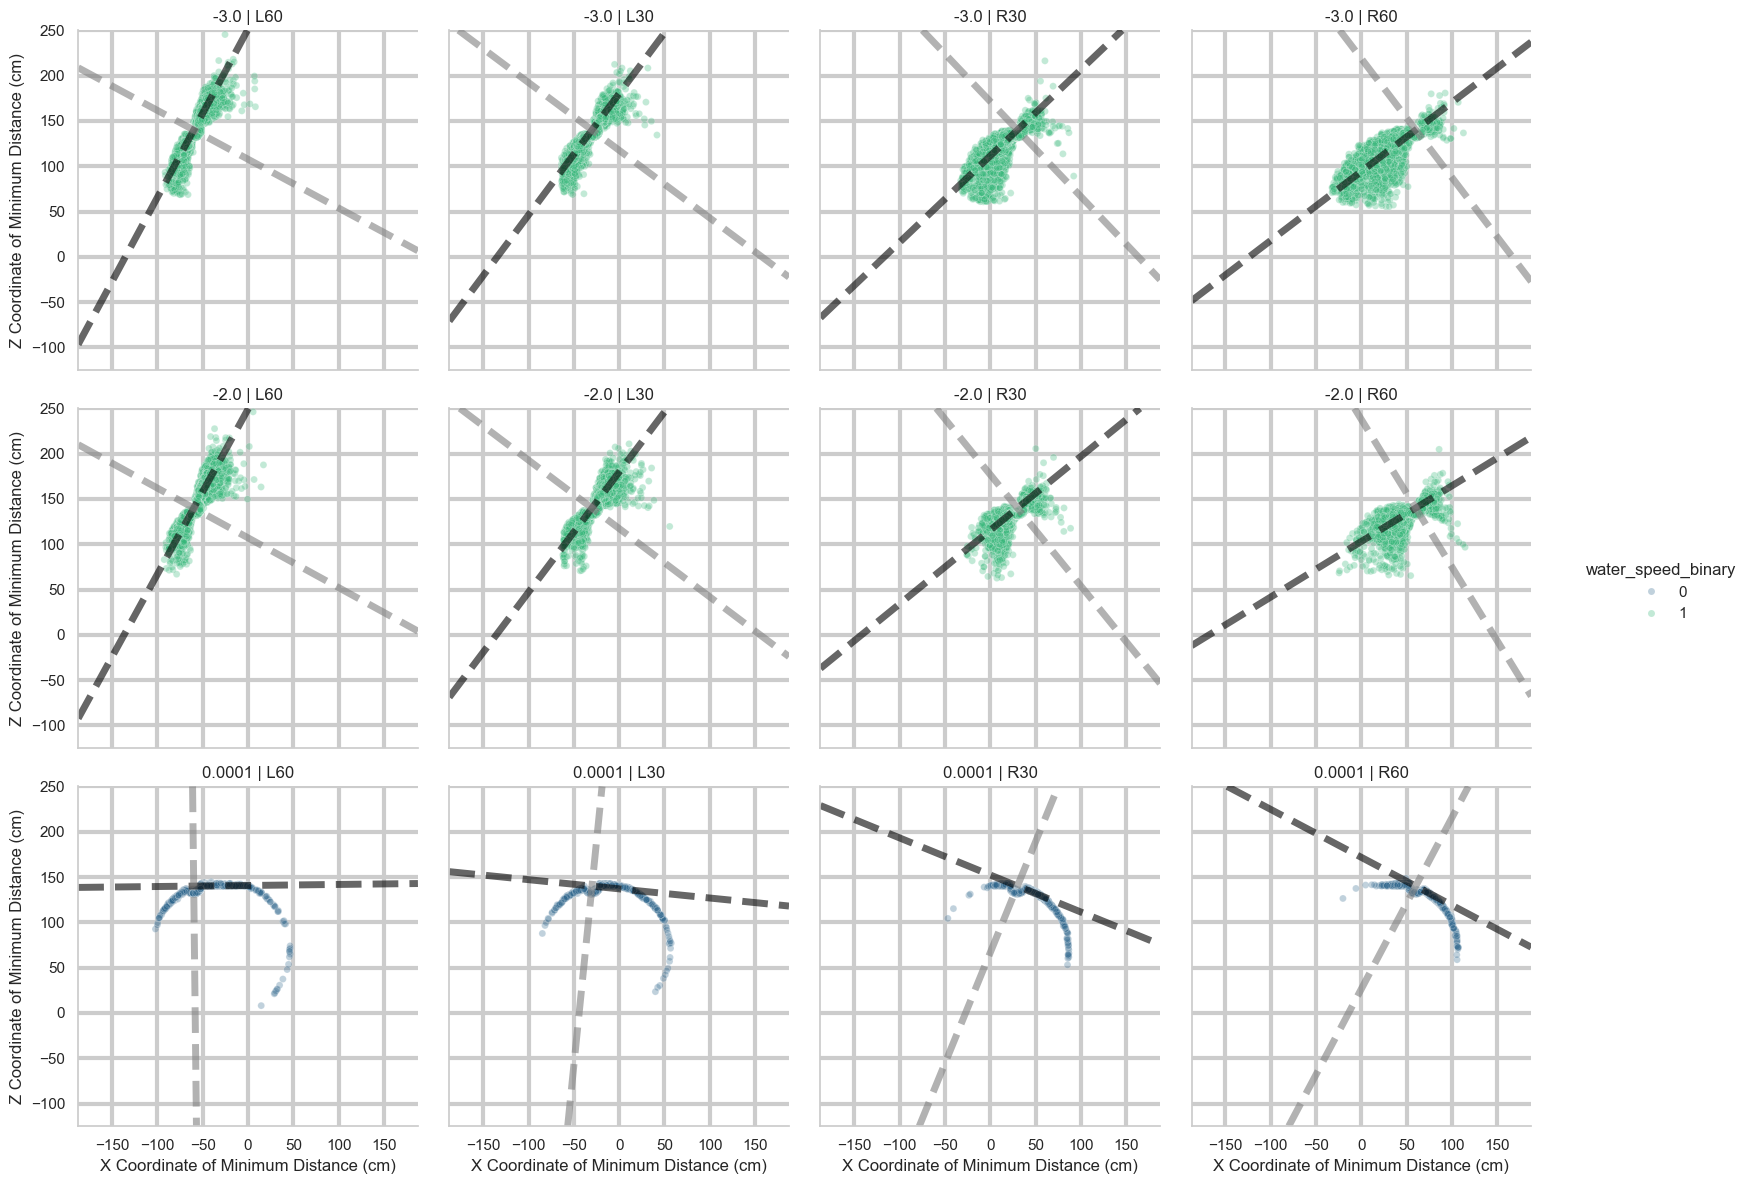

In [43]:
from src.PCA import compute_PCA_summary

features = ['min_pos_from_target_x_cm', 'min_pos_from_target_z_cm']
target_x_col = 'target_position_x_cm'
target_z_col = 'target_position_z_cm'


PCA_table = compute_PCA_summary(df_small_filt,
            features = features,
            group_cols = ['water_speed_m_s','target_position_x_cm'],
            water_col = 'water_speed_m_s',
            n_components=2
            )
PCA_table

# extract relevant columns
PCA_table_small = PCA_table.iloc[:, 0:9].copy()
PCA_table_small


# merge small summary table into raw df with trial-by-trial data
df_angles = df_small_filt.copy()
 
group_cols = ['water_speed_m_s','target_position_x_cm']
new_cols = ['pc_vector_1_angle','pc_vector_1_pca_center_x','pc_vector_1_pca_center_z','pc_vector_1_c_X','pc_vector_1_c_Z']

df_angles_v = df_angles.merge(PCA_table_small[group_cols + new_cols], how="left", on=group_cols)

from src.PCA import compute_PCA_error

PCA_error_df = compute_PCA_error(trial_df=df_angles_v,
                  pc_deg='pc_vector_1_angle',
                  target_x_col=target_x_col,
                  target_z_col=target_z_col,
                  features = features,
                  group_cols = ['water_speed_m_s','target_position_x_cm'],
                  water_col = 'water_speed_m_s',
                  show_plots = True
                 )


from src.plotting import plot_min_x_z

plot_min_x_z(PCA_error_df,
             c_col='target_x_label',
             r_col='water_speed_m_s',
             slope_array=[[61.685831, 53.243388, 43.616088, 37.305211], # 3.0 m/s
                          [61.234584, 52.969086, 39.132036, 31.544813], # 2.0 m/s
                          [0.656367, -5.779064, -22.239128, -27.872954]], # 0.0 m/s
             target_x_array=[-60, -30, 30, 60], 
             show_slopes=True,
             show_orthogonal=True,
             show_target=False,
             x_col_title = 'X Coordinate of Minimum Distance (cm)',
             y_col_title = 'Z Coordinate of Minimum Distance (cm)',
             context='notebook'
            )

### Signed Minimum Metric Error

In [59]:

PCA_error_df['min_distance_target_x_cm'] = PCA_error_df['min_pos_from_target_x_cm']-PCA_error_df['target_position_x_cm'] + 3.75
PCA_error_df['min_distance_target_z_cm'] = PCA_error_df['min_pos_from_target_z_cm']-PCA_error_df['target_position_z_cm'] + 3.75
PCA_error_df['PCA_sign'] = np.sign(PCA_error_df['PCA_error_X_cm'])

PCA_error_df['flip_min_distance_xPCA'] = np.sqrt(PCA_error_df['min_distance_target_x_cm']**2 + PCA_error_df['min_distance_target_z_cm']**2) * PCA_error_df['PCA_sign']*-1



In [49]:
print(PCA_error_df.groupby(['target_hit'])['flip_min_distance_xPCA'].agg(['min','max']))

                   min         max
target_hit                        
False      -150.197688  110.155933
True        -14.710717   11.335187


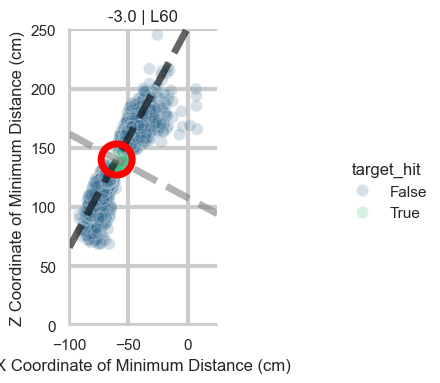

In [11]:
# for illustration, filter ONLY L60
L60_df = PCA_error_df[(PCA_error_df['target_x_label'] == 'L60') & (PCA_error_df['water_speed_m_s'] == -3.0)]

from src.plotting import plot_min_x_z
plot_min_x_z(L60_df,
             c_col='target_x_label',
             r_col='water_speed_m_s',
             slope_array=[[61.685831], # 3.0 m/s
                          [61.234584], # 2.0 m/s
                          [0.656367]], # 0.0 m/s
             hue_col='target_hit',
             target_x_array=[-60], 
             show_slopes=True,
             show_orthogonal=True,
             show_target=True,
             x_col_title = 'X Coordinate of Minimum Distance (cm)',
             y_col_title = 'Z Coordinate of Minimum Distance (cm)',
             context='notebook'
            )

# -100, 50

In [55]:

for t in np.unique(PCA_error_df['target_x_label']):

    df_subset = PCA_error_df[PCA_error_df['target_x_label'] == t]
    
    scatter = plt.scatter(df_subset['min_pos_from_target_x_cm'], df_subset['min_pos_from_target_z_cm'], c = df_subset['PCA_sign'])
    plt.legend(*scatter.legend_elements(), title="PCA Sign")
    plt.show()
    
    print(np.abs(df_subset['min_pos_from_target_x_cm']).min())

KeyError: 'PCA_sign'

# Baseline & Cleaning

Cleaning Baseline outliers: drops trials that are greater than 2.0 SD from the baseline mean

--- Baseline Trial Outlier Removal (flip_min_distance_xPCA) ---
Baseline Mean: -7.5021, SD: 17.0345
SD Threshold: 2.0 (34.0690 units)
Trials removed: 144 / 2814 total baseline trials
PCA_error_df (41480, 53)
clean_df (41336, 53)
hit min None
hit max None


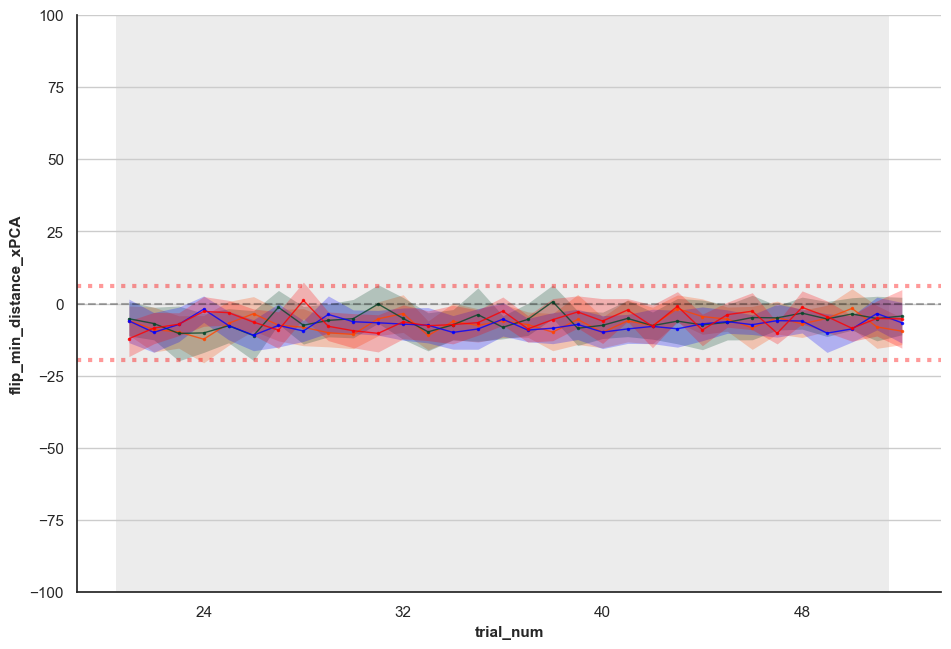

In [61]:
from src.cleaning import remove_baseline_outlier_trials_threshold_sd

# tag baseline outlier ppid
clean_df = remove_baseline_outlier_trials_threshold_sd(PCA_error_df,
                            y_col='flip_min_distance_xPCA',
                            trial_col='trial_num'
                               )

print('PCA_error_df', PCA_error_df.shape)
print('clean_df', clean_df.shape)

from src.plotting import plot_all_trials

df_baseline_clean = clean_df[clean_df['phase'] == 'baseline']

plot_all_trials(df_baseline_clean, 
                     col_col =None,
                     row_col=None,
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'flip_min_distance_xPCA', 
                     x_col='trial_num',
                     context='notebook', 
                     transition_col='water_speed_binary',
                     font_scale=3,
                     marker_size=1.5,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True,
                     show_sd_line=True
                    )




Across ALL trials, remove outliers greater than 3.0 SD

         phase  trial_num  removed_count
0   training_1        109              1
1   training_1        161              1
2   training_1        202              1
3    washout_1        203              1
4    washout_1        204              2
..         ...        ...            ...
60   washout_2        480              1
61   washout_2        489              1
62   washout_2        490              2
63   washout_2        491              2
64   washout_2        493              1

[65 rows x 3 columns]
--- Trial-by-Trial Outlier Removal (flip_min_distance_xPCA) ---
SD Threshold: 3.0
Trials removed: 82 / 41336 total rows


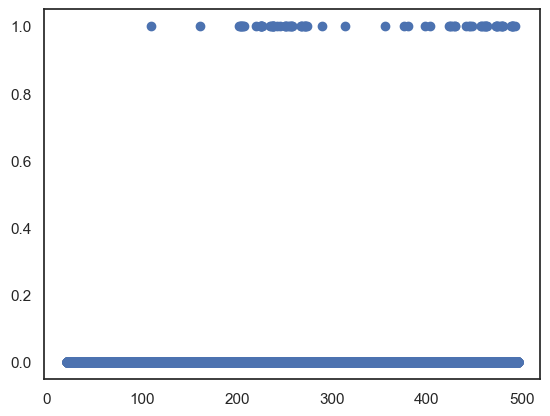

(41254, 54)


In [63]:
from src.cleaning import remove_outliers_per_trial

clean_df_ALL = remove_outliers_per_trial(clean_df,
                              y_col='flip_min_distance_xPCA',
                              trial_col='trial_num',
                              water_col='water_speed_m_s',
                              target_col='target_x_label',
                              phase_col='phase'
                             )

print(clean_df_ALL.shape)

Washout outliers

In [12]:
# from src.washout_outliers import label_outliers_washout

# clean_df_ALL = label_outliers_washout(clean_df_ALL,
#                        phase_col='phase',
#                        water_state_col='water_speed_binary',
#                        threshold_col='flip_min_distance_xPCA',
#                        threshold_val=50.0
#                       )
# clean_df_ALL = clean_df_ALL[clean_df_ALL['is_outlier'] == False].copy()
# print(clean_df_ALL.shape)

NameError: name 'clean_df_ALL' is not defined

# Baseline Correct and Export Preprocessed dfs

In [65]:
# clean_df_ALL = clean_df.copy()
# print(clean_df_ALL.shape)

from src.baseline_correct import baseline_correct

df_bc = baseline_correct(data = clean_df_ALL, #clean_df_ALL
                phase_col = 'phase',
                baseline_string='baseline',
                y_col='launch_deviation',
                PCA_col='flip_min_distance_xPCA'
                ) 

# Extract and join unique experiment strings
exp_tags = "_".join(df_bc['experiment'].unique().astype(str))

# Extract unique water speeds, rounded to prevent floating point noise
speeds = df_bc['water_speed_m_s'].unique()
speed_tags = "_".join([str(round(s, 1)).replace('-', 'neg').replace('.', '_') for s in np.sort(speeds)])

# construct the combined filename & save
file_name = f"PCA_error_{exp_tags}_speed_{speed_tags}.csv"
file_path = f"..\\data\\dual_generalization\\{file_name}"

print(df_bc.columns)
df_bc.to_csv(file_path, index=False)
print(f"Saved: {file_path}")



from src.early_late_exposure import early_late_phase_new

# first and last 4 trials
early_late_phase_df_4 = early_late_phase_new(df = df_bc,
                 group_cols = ['ppid_full','set_order','target_x_label','speed_label'],
                 phase_col = 'phase',
                 phases_to_keep=['training_1','training_2'],
                 trial_col = 'phase_target_trial_num',
                 n_trials = 4
                ).copy()


# first and last 2 trials
early_late_phase_df_2 = early_late_phase_new(df = df_bc,
                 group_cols = ['ppid_full','set_order','target_x_label','speed_label'],
                 phase_col = 'phase',
                 phases_to_keep=['training_1','training_2'],
                 trial_col = 'phase_target_trial_num',
                 n_trials = 2
                ).copy()

# Extract and join unique experiment strings
unique_exps = df_bc['experiment'].unique().astype(str)
exp_tags = "_".join(unique_exps[:2]) 
if len(unique_exps) > 2:
    exp_tags += "_etc"
    
# Extract unique water speeds, rounded to prevent floating point noise
speeds = early_late_phase_df_4['water_speed_m_s'].unique()
speed_tags = "_".join([str(round(s, 1)).replace('-', 'neg').replace('.', '_') for s in np.sort(speeds)])

# construct the combined filename & save
file_name_4 = f"early_late_4_phase_PCA_error_{exp_tags}_speed_{speed_tags}.csv"
file_name_2 = f"early_late_2_phase_PCA_error_{exp_tags}_speed_{speed_tags}.csv"

file_path_4 = f"..\\data\\dual_generalization\\{file_name_4}"
file_path_2 = f"..\\data\\dual_generalization\\{file_name_2}"

early_late_phase_df_4.to_csv(file_path_4, index=False)
early_late_phase_df_2.to_csv(file_path_2, index=False)

print(f"Saved: {file_path}")

C:\Users\jacob\water_current_MA\src\baseline_correct.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_merged.groupby(['target_x_label'])[f"{y_col}_mean"].mean())


target_x_label
L60    0.397386
L30    1.139585
R30    1.949754
R60    1.540521
Name: launch_deviation_mean, dtype: float64
Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_trial_num', 'phase_target_trial_num', 'trial_num_target',
       'global_cycle_num', 'cycle_target_num', 'cycle_TargetxPhase_num',
       'launch_angle', 'launch_deviation', 'launch_Speed',
       'distance_from_target', 'ball_dist_to_center_cm', 'signed_euclidean_cm',
       'lateral_error_x_cm', 'depth_error_z_cm', 'target_hit',
       'water_speed_binary', 'water_speed_m_s', 'sign_label', 'set_order',
       'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90', 'ball_pos_x', 'ball_pos_z', 'final_ball_pos_x',
       'pc_vector_1_angle', 'pc_vector_1_pca_center_x',
       'pc_vector_1_pca_center_z', 'pc_vector_1_c_X', 'pc_vector_1_c_Z',
       'pc_rad', 'centered_x', 'centered_z', 

C:\Users\jacob\water_current_MA\src\early_late_exposure.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby(group_cols + [phase_col])
C:\Users\jacob\water_current_MA\src\early_late_exposure.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby(group_cols + [phase_col])


Saved: ..\data\dual_generalization\PCA_error_projectile_experiment _S1-projectile_experiment_S2-projectile_experiment_S1_3.0M-projectile_experiment 1_S2_3.0M-projectile_experiment 1_speed_neg3_0_neg2_0_0_0.csv


Baseline

52
hit min None
hit max None


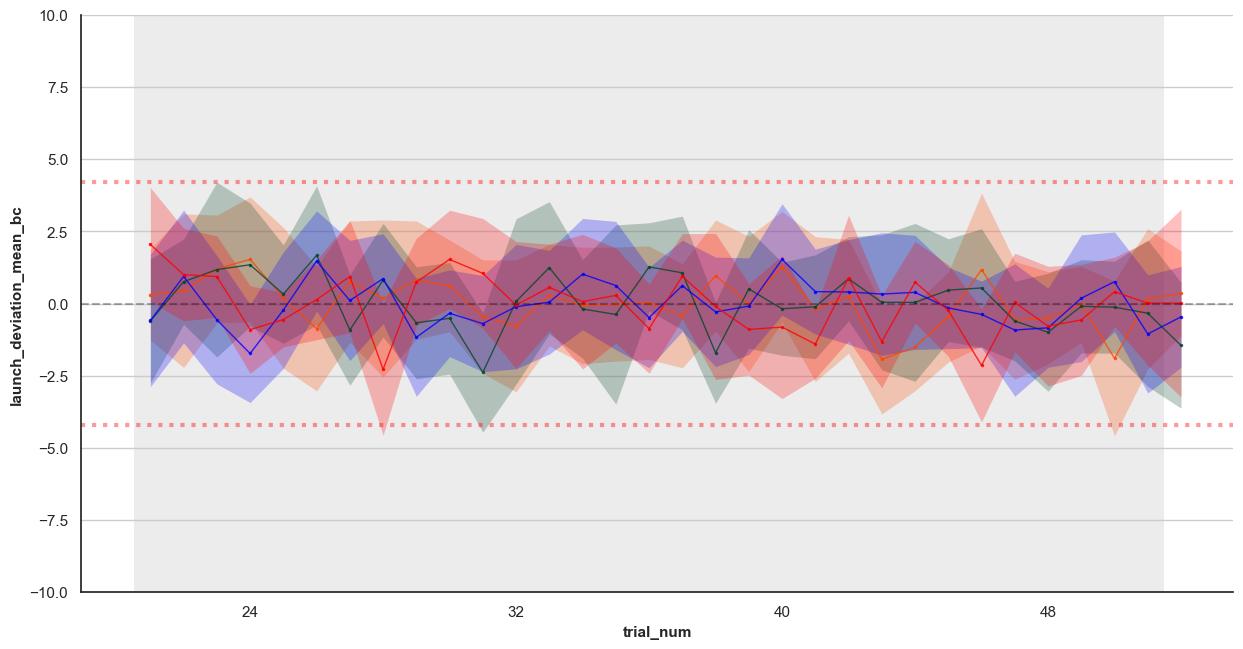

In [205]:
from src.plotting import plot_all_trials

df_bc_baseline = df_bc[df_bc['phase'] == 'baseline']
print(df_bc_baseline['trial_num'].max())

plot_all_trials(df_bc_baseline, 
                     col_col =None,
                     row_col=None,
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_deviation_mean_bc', 
                     x_col='trial_num',
                     context='notebook', 
                     transition_col='water_speed_binary',
                     font_scale=3,
                     marker_size=1.5,
                     estimator='mean',
                     y_lim=(-10,10),
                     show_zero_line=True,
                     show_sd_line=True
                    )




In [23]:
df_bc_baseline.groupby(['target_x_label', 'speed_label'])['launch_deviation'].mean()

C:\Users\jacob\AppData\Local\Temp\ipykernel_13152\1376039442.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_bc_baseline.groupby(['target_x_label', 'speed_label'])['launch_deviation'].mean()


target_x_label  speed_label
L60             -3.0           0.377062
                -2.0           0.420308
L30             -3.0           1.126446
                -2.0           0.849550
R30             -3.0           1.228980
                -2.0           2.458658
R60             -3.0           1.107851
                -2.0           1.901642
Name: launch_deviation, dtype: float64

# Plot all trials

C:\Users\jacob\AppData\Local\Temp\ipykernel_20160\880351242.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_bc.groupby(['phase'])['trial_num'].agg(['min','max']))


                   min    max
phase                        
familiarization    NaN    NaN
baseline          21.0   52.0
training_1        53.0  202.0
washout_1        203.0  274.0
training_2       275.0  424.0
washout_2        425.0  496.0
hit min None
hit max None


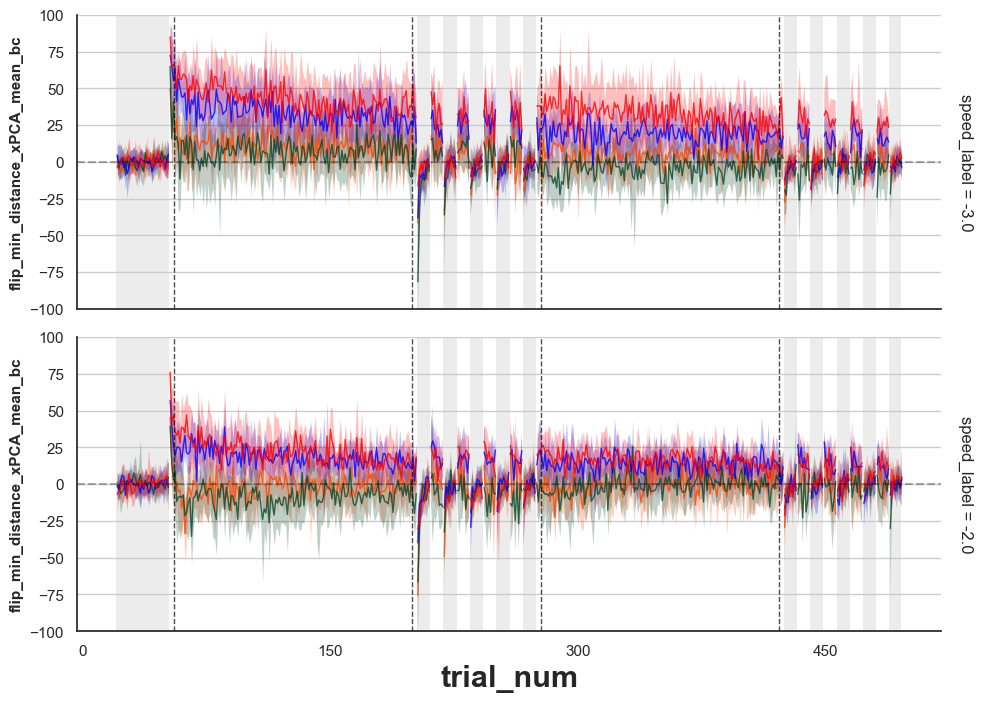

In [19]:
from src.plotting import plot_all_trials

print(df_bc.groupby(['phase'])['trial_num'].agg(['min','max']))

plot_all_trials(df_bc, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'flip_min_distance_xPCA_mean_bc', # 
                     x_col='trial_num',
                     vertical_list=[55.5,199.5, 277.5,421.5],
                     hit_col='target_hit',
                     ref_range_col='flip_min_distance_xPCA_mean_bc',
                     no_connect_col='phase',
                     context='notebook', 
                     transition_col='water_speed_binary',
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True
                    )                    

<function matplotlib.pyplot.show(close=None, block=None)>

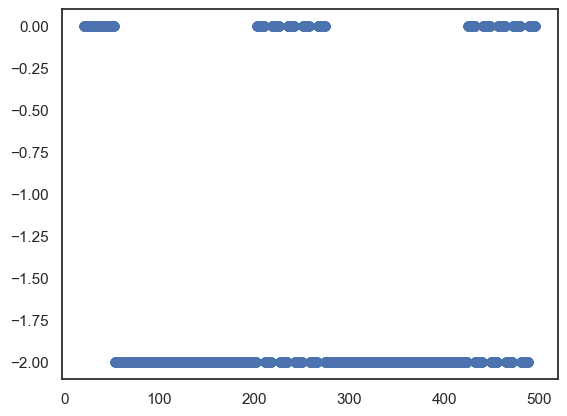

In [107]:
plt.scatter(df_bc_2['trial_num'], df_bc_2['water_speed_m_s'])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

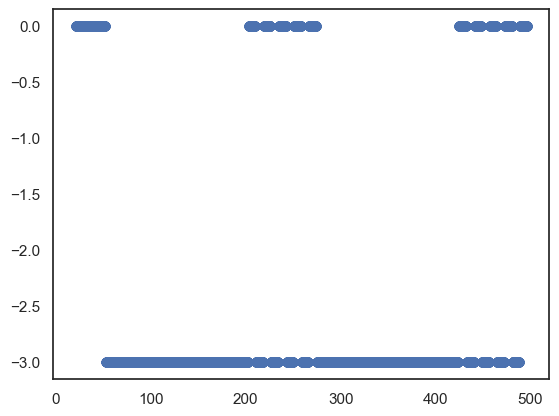

In [105]:
plt.scatter(df_bc_3['trial_num'], df_bc_3['water_speed_m_s'])
plt.show

In [103]:
df_bc_3

<class 'pandas.core.frame.DataFrame'>
Index: 20981 entries, 20273 to 41253
Data columns (total 62 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   experiment                        20981 non-null  category
 1   ppid_full                         20981 non-null  category
 2   speed_label                       20981 non-null  category
 3   target_x_label                    20981 non-null  category
 4   target_position_x_cm              20981 non-null  float64 
 5   target_position_z_cm              20981 non-null  float64 
 6   trial_num                         20981 non-null  int32   
 7   phase                             20981 non-null  category
 8   phase_trial_num                   20981 non-null  int64   
 9   phase_target_trial_num            20981 non-null  int64   
 10  trial_num_target                  20981 non-null  int32   
 11  global_cycle_num                  20981 non-null  int64

In [69]:
df_bc_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20983 entries, 19798 to 40780
Data columns (total 62 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   experiment                        20983 non-null  category
 1   ppid_full                         20983 non-null  category
 2   speed_label                       20983 non-null  category
 3   target_x_label                    20983 non-null  category
 4   target_position_x_cm              20983 non-null  float64 
 5   target_position_z_cm              20983 non-null  float64 
 6   trial_num                         20983 non-null  int32   
 7   phase                             20983 non-null  category
 8   phase_trial_num                   20983 non-null  int64   
 9   phase_target_trial_num            20983 non-null  int64   
 10  trial_num_target                  20983 non-null  int32   
 11  global_cycle_num                  20983 non-null  int64

In [67]:
df_bc_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19798 entries, 0 to 19797
Data columns (total 62 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   experiment                        19798 non-null  category
 1   ppid_full                         19798 non-null  category
 2   speed_label                       19798 non-null  category
 3   target_x_label                    19798 non-null  category
 4   target_position_x_cm              19798 non-null  float64 
 5   target_position_z_cm              19798 non-null  float64 
 6   trial_num                         19798 non-null  int32   
 7   phase                             19798 non-null  category
 8   phase_trial_num                   19798 non-null  int64   
 9   phase_target_trial_num            19798 non-null  int64   
 10  trial_num_target                  19798 non-null  int32   
 11  global_cycle_num                  19798 non-null  int64   


Launch Deviation (degrees: relative to target)

hit min None
hit max None


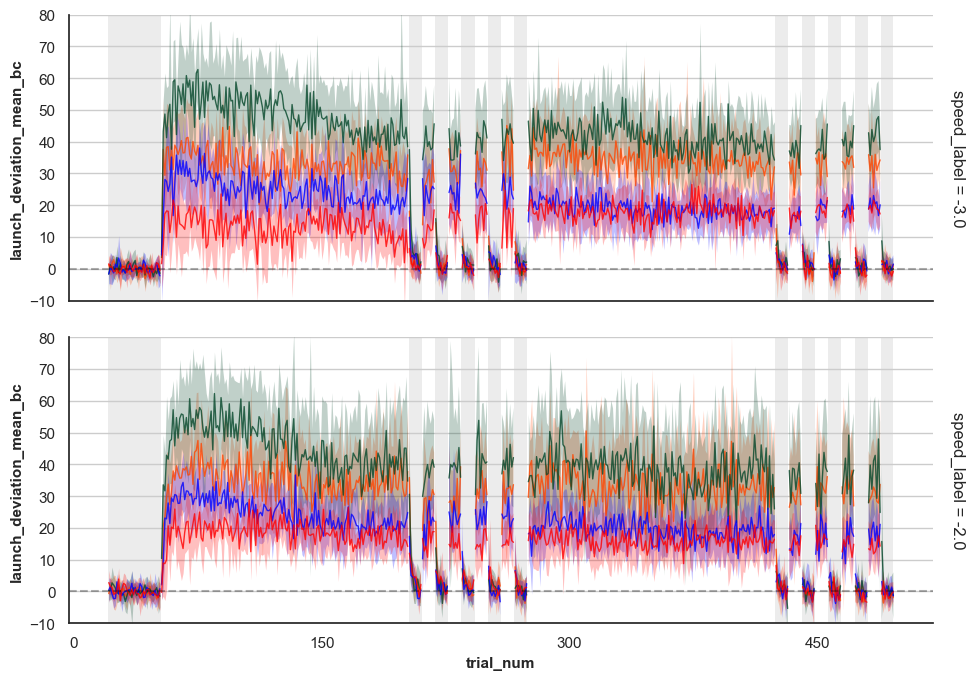

In [28]:
from src.plotting import plot_all_trials

plot_all_trials(df_bc, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_deviation_mean_bc', # 
                     x_col='trial_num',
                     vertical_list= None,
                     hit_col='target_hit',
                     ref_range_col=None,
                     no_connect_col='phase',
                     context='notebook', 
                     transition_col='water_speed_binary',
                     marker_size=0.0,
                     estimator='mean',
                     y_lim=(-10,80),
                     show_zero_line=True
                    )                    

Launch Speed (m/s)

hit min None
hit max None


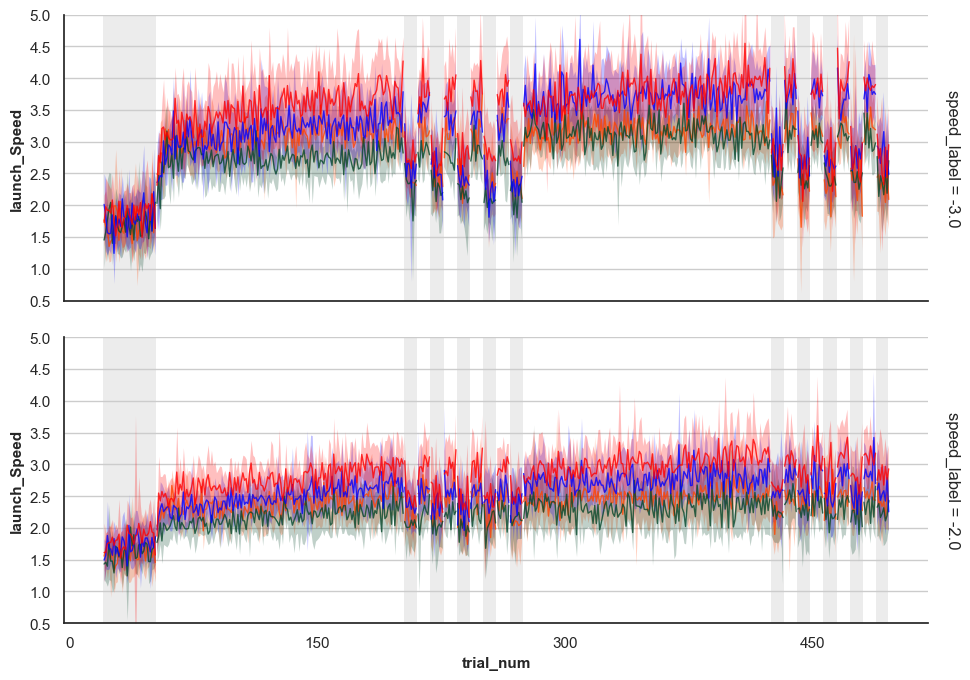

In [51]:
from src.plotting import plot_all_trials

plot_all_trials(df_bc, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_Speed', # 
                     x_col='trial_num',
                     vertical_list= None,
                     hit_col='target_hit',
                     ref_range_col=None,
                     no_connect_col='phase',
                     context='notebook', 
                     transition_col='water_speed_binary',
                     marker_size=0.0,
                     estimator='mean',
                     y_lim=(0.5,5.0),
                     show_zero_line=True
                    )                    

First and Last 4 trials - Training Phase 1

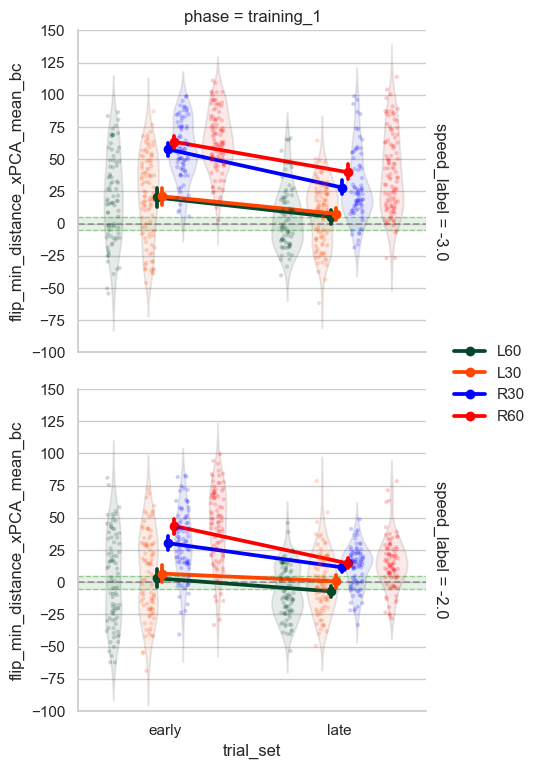

In [51]:
early_late_phase_df_4_t1 = early_late_phase_df_4[early_late_phase_df_4['phase'] == "training_1"]

from src.plotting import plot_slopes
plot_slopes(early_late_phase_df_4_t1,
                         x_col='trial_set',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col='phase',
                         facet_row= 'speed_label'
                            )



First and Last 4 trials - Training Phase 2

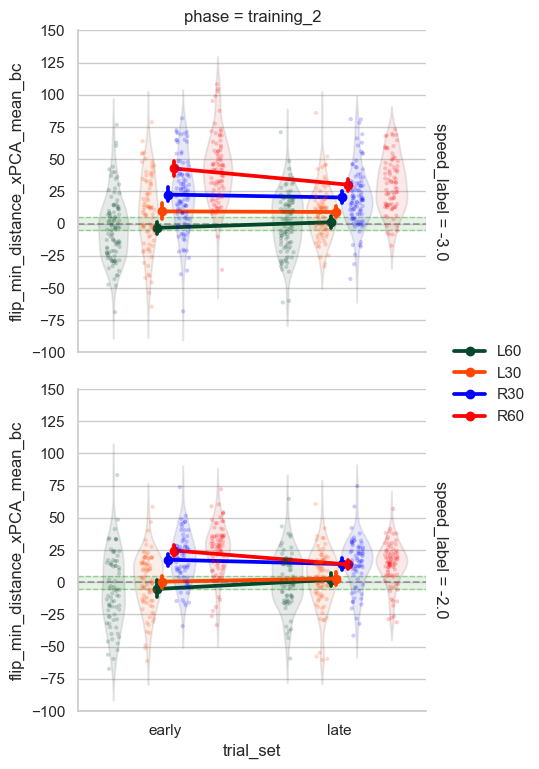

In [19]:
early_late_phase_df_4_t2 = early_late_phase_df_4[early_late_phase_df_4['phase'] == "training_2"]

from src.plotting import plot_slopes
plot_slopes(early_late_phase_df_4_t2,
                         x_col='trial_set',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col='phase',
                         facet_row= 'speed_label'
                            )



First and Last 2 trials - Training Phase 1

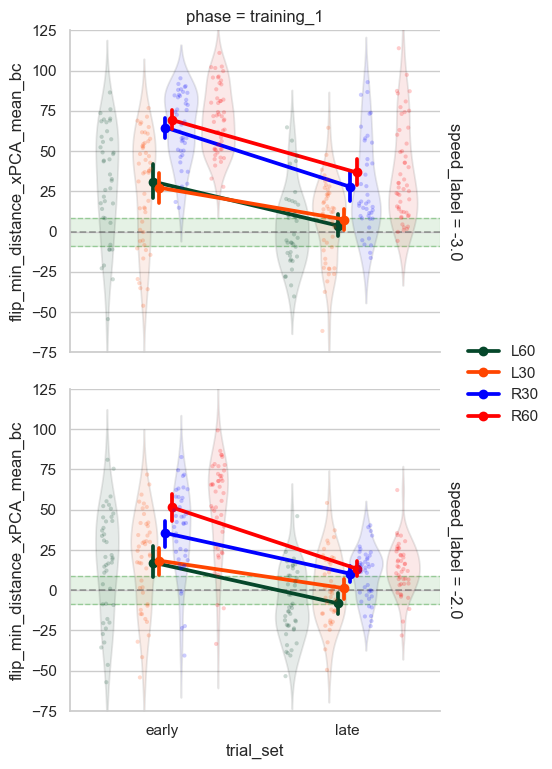

In [89]:
from src.plotting import plot_slopes

early_late_phase_df_2_t1 = early_late_phase_df_2[early_late_phase_df_2['phase'] == "training_1"]

plot_slopes(early_late_phase_df_2_t1,
                         x_col='trial_set',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col='phase',
                         facet_row= 'speed_label'
                            )



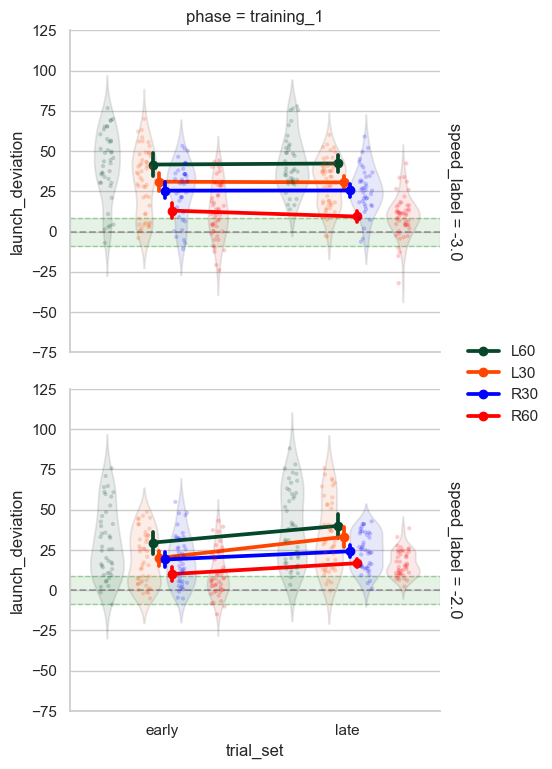

In [87]:
from src.plotting import plot_slopes

early_late_phase_df_2_t1 = early_late_phase_df_2[early_late_phase_df_2['phase'] == "training_1"]

plot_slopes(early_late_phase_df_2_t1,
                         x_col='trial_set',
                         y_col='launch_deviation',
                         hue_var='target_x_label', 
                         facet_col='phase',
                         facet_row= 'speed_label'
                            )



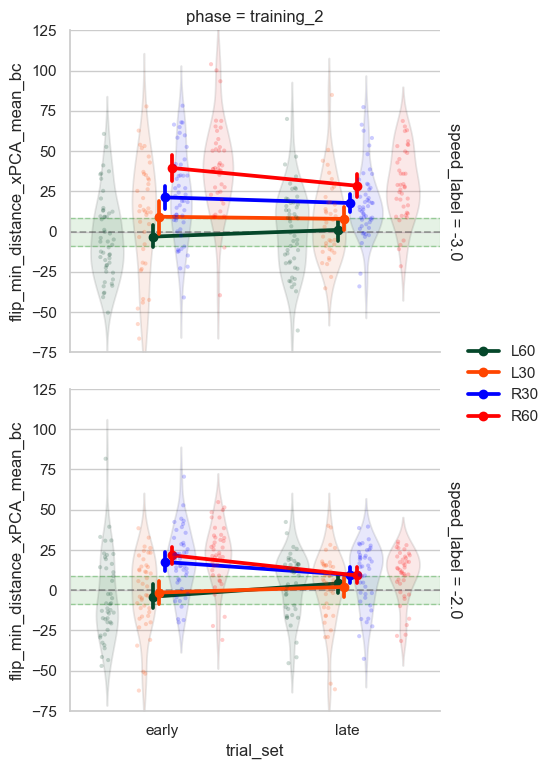

In [91]:
from src.plotting import plot_slopes

early_late_phase_df_2_t2 = early_late_phase_df_2[early_late_phase_df_2['phase'] == "training_2"]

plot_slopes(early_late_phase_df_2_t2,
                         x_col='trial_set',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col='phase',
                         facet_row= 'speed_label'
                            )


# Between-Subjects Transfer

First 4 trials of T1 (*Naive*) vs First 4 trials of T2 (*Experienced*) on the SAME target

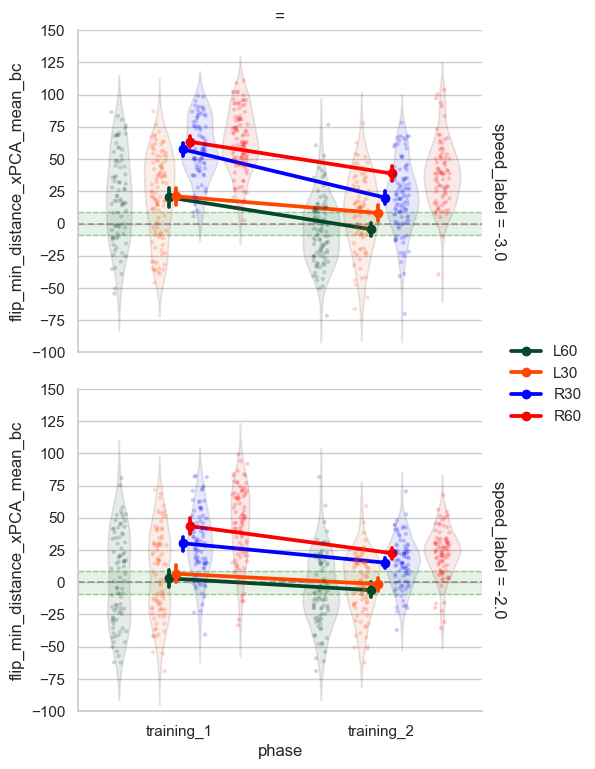

In [63]:

early_df_4 = early_late_phase_df_4[early_late_phase_df_4['trial_set'] == 'early'].copy()
early_df_4['phase'] = early_df_4['phase'].astype(str) # for plotting
   


from src.plotting import plot_slopes
plot_slopes(early_df_4,
                         x_col='phase',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col=None,
                         facet_row='speed_label',
                         facet_aspect=1.0
            
                            )



In [43]:
print(early_df_4.groupby(['ppid_full','phase','target_x_label'])['trial_num'].count().head(20))
print(early_df_4.groupby(['ppid_full','phase','target_x_label'])['trial_num'].count().head(20))





ppid_full  phase       target_x_label
1_neg3     training_1  L60               4
                       L30               0
                       R30               4
                       R60               0
           training_2  L60               0
                       L30               4
                       R30               0
                       R60               4
p000_neg2  training_1  L60               4
                       L30               0
                       R30               4
                       R60               0
           training_2  L60               0
                       L30               4
                       R30               0
                       R60               4
p002_neg3  training_1  L60               0
                       L30               4
                       R30               0
                       R60               4
Name: trial_num, dtype: int64
ppid_full  phase       target_x_label
1_neg3     training_1  L60        

C:\Users\jacob\AppData\Local\Temp\ipykernel_16028\462375389.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(early_df_4.groupby(['ppid_full','phase','target_x_label'])['trial_num'].count().head(20))
C:\Users\jacob\AppData\Local\Temp\ipykernel_16028\462375389.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(early_df_4.groupby(['ppid_full','phase','target_x_label'])['trial_num'].count().head(20))


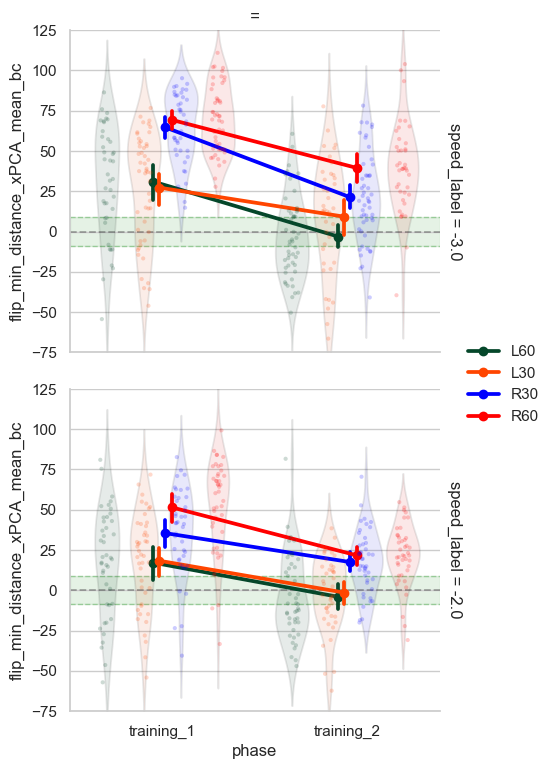

In [93]:

early_df_2 = early_late_phase_df_2[early_late_phase_df_2['trial_set'] == 'early'].copy()
early_df_2['phase'] = early_df_2['phase'].astype(str) # for plotting

from src.plotting import plot_slopes
plot_slopes(early_df_2,
                         x_col='phase',
                         y_col='flip_min_distance_xPCA_mean_bc',
                         hue_var='target_x_label', 
                         facet_col=None,
                         facet_row='speed_label'            
                            )



# Washout

In [174]:

# filter to baseline
df_baseline = df_bc[df_bc['phase'] == 'baseline'].copy()
max_trials = df_baseline['trial_num'].max()

# grab last 8 trials of baseline 
df_baseline_last8 = df_baseline[df_baseline['trial_num'] >= max_trials - 8]

# washout 1 only
df_w1 = df_bc[df_bc['phase'] == 'washout_1'].copy()
# only still-water
df_w1 = df_w1[df_w1['water_speed_binary'] == 0].copy()

df_baseline_w1 = pd.concat([df_baseline_last8, df_w1])


from src.add_cycles import add_cycles # function that adds a cycle/block counter globally and per target
df_baseline_w1_cycle8 = add_cycles(df_baseline_w1,
                       n_trials=8,
                       ppid_col='ppid_full',
                       target_col='target_x_label',
                       inc_phase=True
                       ).copy()






In [176]:
df_baseline_w1_cycle8.columns

Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_trial_num', 'phase_target_trial_num', 'trial_num_target',
       'global_cycle_num', 'cycle_target_num', 'cycle_TargetxPhase_num',
       'launch_angle', 'launch_deviation', 'launch_Speed',
       'distance_from_target', 'ball_dist_to_center_cm', 'signed_euclidean_cm',
       'lateral_error_x_cm', 'depth_error_z_cm', 'target_hit',
       'water_speed_binary', 'water_speed_m_s', 'sign_label', 'set_order',
       'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90', 'ball_pos_x', 'ball_pos_z', 'final_ball_pos_x',
       'pc_vector_1_angle', 'pc_vector_1_pca_center_x',
       'pc_vector_1_pca_center_z', 'pc_vector_1_c_X', 'pc_vector_1_c_Z',
       'pc_rad', 'centered_x', 'centered_z', 'unrotated_x', 'unrotated_z',
       'tgt_centered_x', 'tgt_centered_z', 'tgt_unrotated_x',
       'tgt_unrotated_z', 'PCA_

In [180]:
tmp = df_baseline_w1_cycle8[df_baseline_w1_cycle8['ppid_full'] == 'p000_neg2']

tmp[['ppid_full','phase','target_x_label','trial_num','trial_within_cyclexPhase','water_speed_binary','launch_deviation']].head(40)

,ppid_full,phase,target_x_label,trial_num,trial_within_cyclexPhase,water_speed_binary,launch_deviation
22,p000_neg2,baseline,L60,45,1,0,3.335991
23,p000_neg2,baseline,R60,46,1,0,7.409919
24,p000_neg2,baseline,R30,47,1,0,-5.711107
25,p000_neg2,baseline,L30,48,1,0,0.862357
26,p000_neg2,baseline,R60,50,2,0,5.218819
27,p000_neg2,baseline,L30,52,2,0,8.155547
176,p000_neg2,washout_1,R30,203,1,0,4.989513
177,p000_neg2,washout_1,L60,204,1,0,0.702291
178,p000_neg2,washout_1,R30,205,2,0,-8.220997
179,p000_neg2,washout_1,L60,206,2,0,-2.153309


Bootstrapped confidence intervals of extent error for first trial per washout cycle

Saved: ..\data\dual_generalization\['washout_1', 'washout_2']_projectile_experiment _S1-projectile_experiment_etc_speed_0.csv


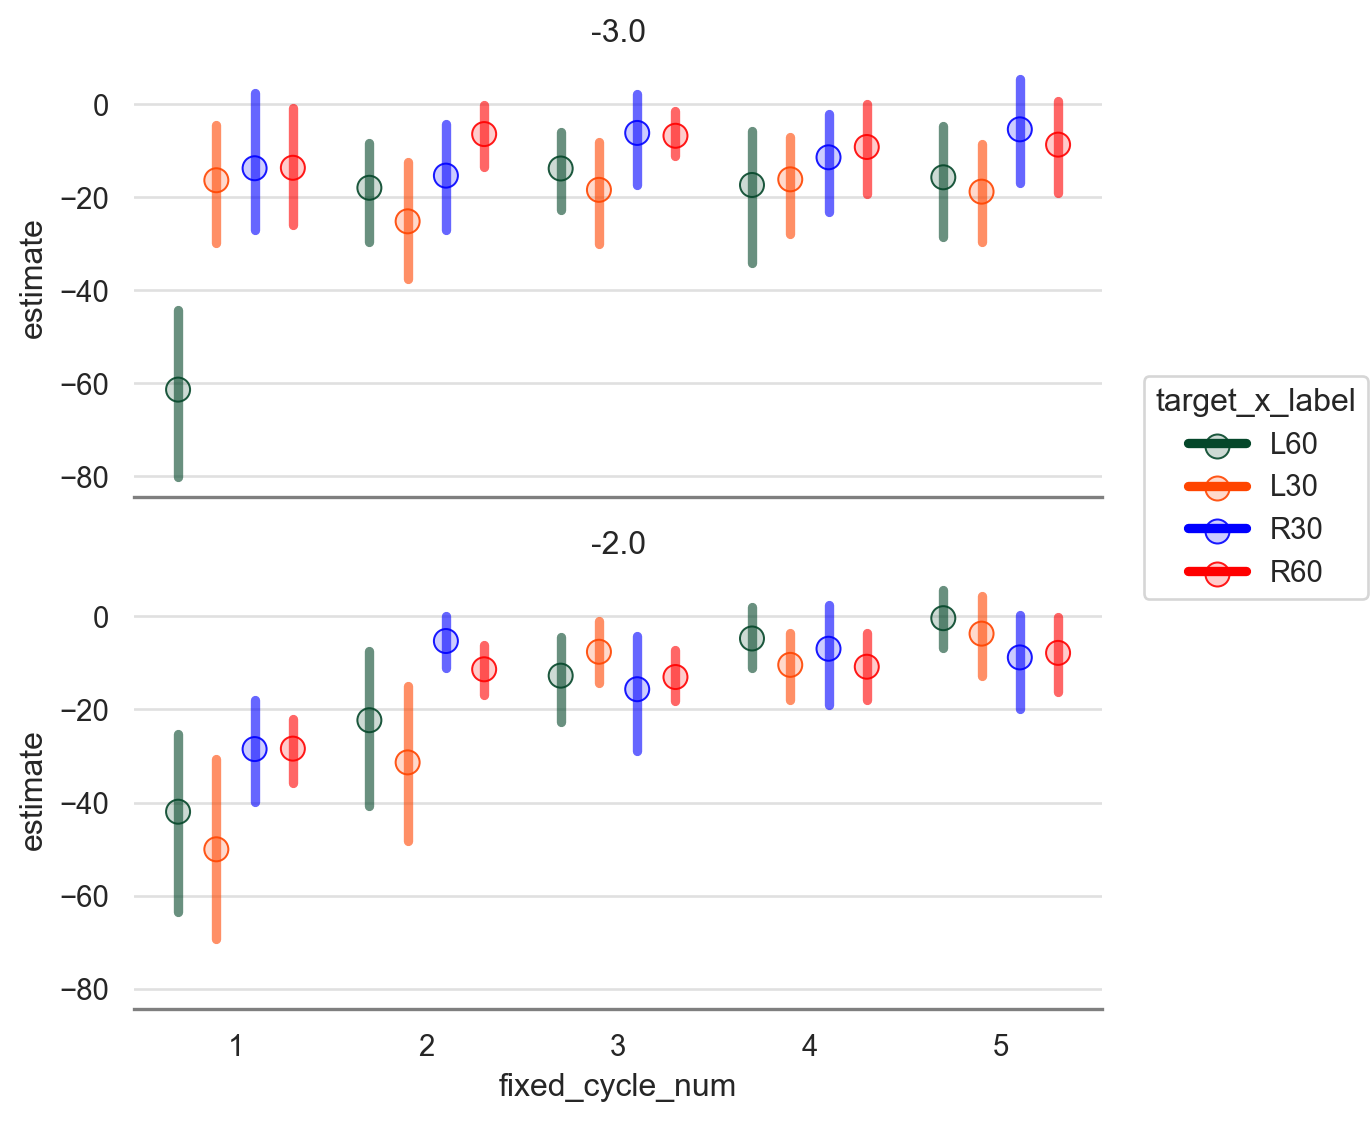

In [97]:
from src.baseline_washout import retain_baseline_washout

df_washout = retain_baseline_washout(df_bc,
                           phase_col='phase',
                           experiment_type ='dual_generalization',
                           phases_to_keep = ['washout_1','washout_2'],
                           experiment_col = 'experiment',
                           water_col = 'water_speed_binary',
                            trial_counter=True)




from src.bootstrap import bootstrap_by_groups, plot_bootstrap_cis
from src.plotting import plot_all_trials_scatter_with_slope

df_washout_p1 = df_washout[df_washout['phase'] == 'washout_1'].copy()

# map early/late
trials_to_keep = [1, 4, 5, 8, 9, 12, 13, 16, 17, 20]
early_late = ['early','late','early','late','early','late','early','late','early','late']
trial_to_rm = dict(zip(trials_to_keep, early_late))
df_washout_p1["early_late"] = df_washout_p1["washout_target_trial_num"].map(trial_to_rm)


df_washout_p1['fixed_cycle_num'] = df_washout_p1['cycle_TargetxPhase_num'].rank(method='dense').astype(int)



df_washout_p1_early = df_washout_p1[df_washout_p1['early_late'] == 'early'].copy()

washout_bootstrap_df = bootstrap_by_groups(df_washout_p1_early,
                          group_cols=['target_x_label','speed_label'],
                          y_col='flip_min_distance_xPCA_mean_bc',
                          x_col='fixed_cycle_num'
                         )


plot_bootstrap_cis(washout_bootstrap_df,
                   x_col='fixed_cycle_num',
                   facet_row='speed_label',
                   hue='target_x_label'
                  )    

In [65]:
print(df_washout_p1.columns)

t = df_washout_p1.sort_values(by=['ppid_full','fixed_cycle_num']).groupby(['ppid_full', 'fixed_cycle_num','target_position_x_cm']).head(2)

print(t[['ppid_full', 'target_position_x_cm', 'washout_target_trial_num','fixed_cycle_num']].head(25))


Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_trial_num', 'phase_target_trial_num', 'trial_num_target',
       'global_cycle_num', 'cycle_target_num', 'cycle_TargetxPhase_num',
       'launch_angle', 'launch_deviation', 'launch_Speed',
       'distance_from_target', 'ball_dist_to_center_cm', 'signed_euclidean_cm',
       'lateral_error_x_cm', 'depth_error_z_cm', 'target_hit',
       'water_speed_binary', 'water_speed_m_s', 'sign_label', 'set_order',
       'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90', 'ball_pos_x', 'ball_pos_z', 'final_ball_pos_x',
       'pc_vector_1_angle', 'pc_vector_1_pca_center_x',
       'pc_vector_1_pca_center_z', 'pc_vector_1_c_X', 'pc_vector_1_c_Z',
       'pc_rad', 'centered_x', 'centered_z', 'unrotated_x', 'unrotated_z',
       'tgt_centered_x', 'tgt_centered_z', 'tgt_unrotated_x',
       'tgt_unrotated_z', 'PCA_

C:\Users\jacob\AppData\Local\Temp\ipykernel_18300\470970381.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t = df_washout_p1.sort_values(by=['ppid_full','fixed_cycle_num']).groupby(['ppid_full', 'fixed_cycle_num','target_position_x_cm']).head(2)


In [147]:
df_c[['global_cycle_num','trial_num','target_x_label','water_speed_binary']].head(80)

,global_cycle_num,trial_num,target_x_label,water_speed_binary
159,47,186,R30,1
160,47,187,L60,1
161,47,188,R30,1
162,48,189,R30,1
163,48,190,L60,1
...,...,...,...,...
2020,49,194,R60,1
2021,49,195,L30,1
2022,49,196,R60,1
2023,50,197,L30,1


hit min None
hit max None


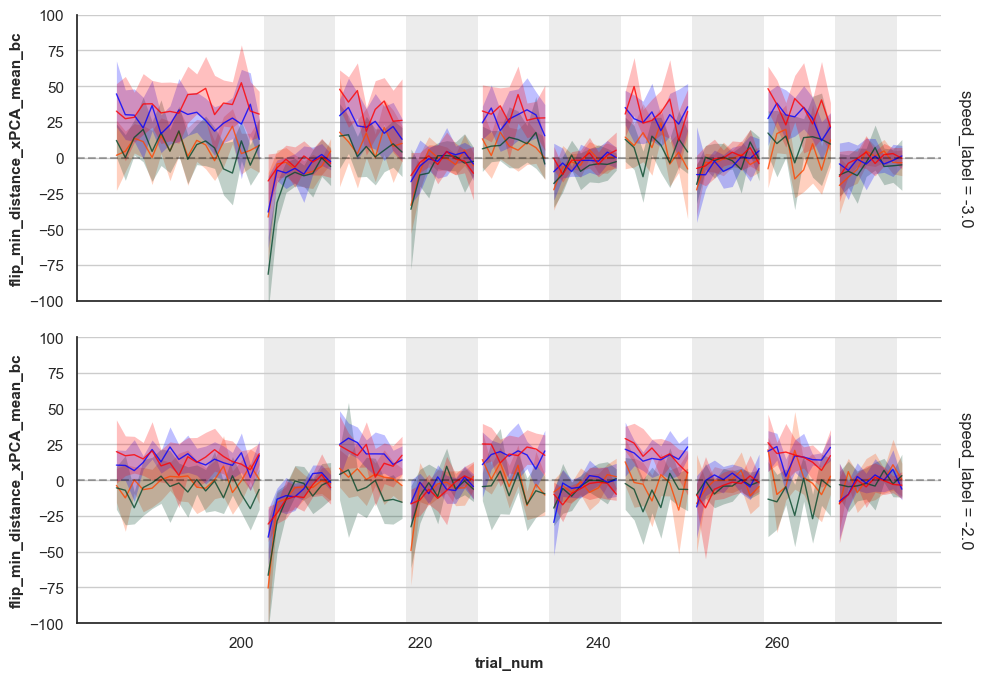

In [21]:
df_t1 = df_bc[df_bc['phase'] == 'training_1']
trial_max = df_t1['trial_num'].max()

df_t1_last16 = df_t1[df_t1['trial_num'] >= trial_max - 16]

# washout 1 only
df_w1 = df_bc[df_bc['phase'] == 'washout_1'].copy()

# early washout 2
df_w2 = df_bc[df_bc['phase'] == 'washout_2'].copy()


# # combine
df_c = pd.concat([df_t1_last16, df_w1])

from src.plotting import plot_all_trials
plot_all_trials(df_c, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'flip_min_distance_xPCA_mean_bc', # launch_deviation_mean_bc
                     x_col='trial_num',
                     vertical_list=[],
                     hit_col='target_hit',
                     ref_range_col='signed_euclidean_cm',
                     no_connect_col=['phase','water_speed_binary'],
                     context='notebook', 
                     transition_col='water_speed_binary',
                     marker_size=0.0,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True
                    )                    

hit min -5.4465
hit max 5.1948


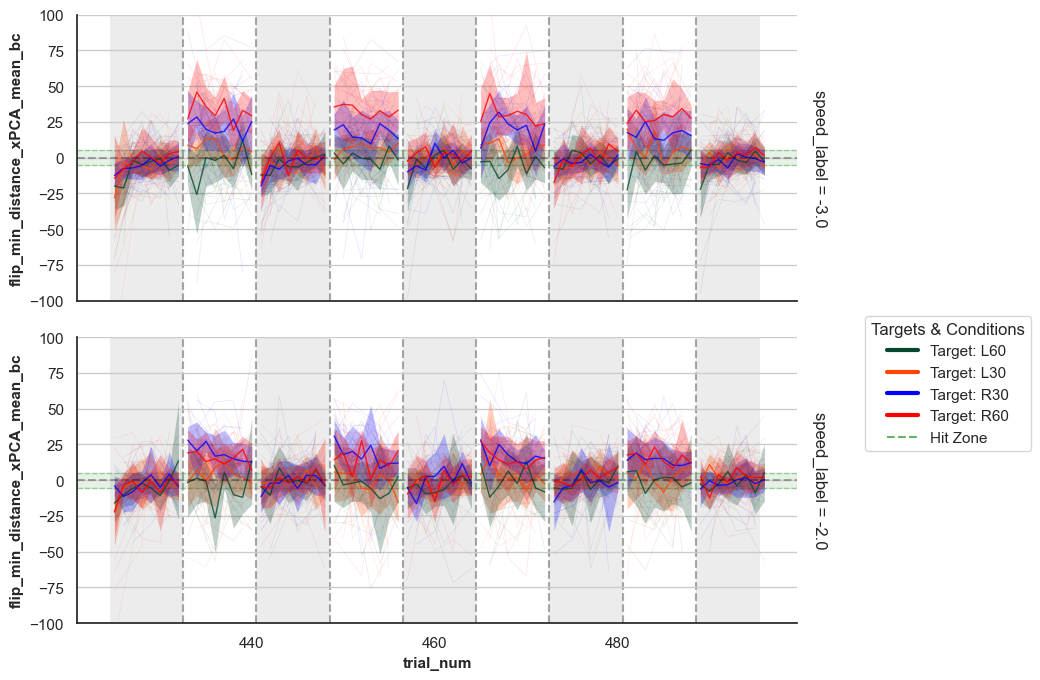

In [35]:
from src.plotting import plot_all_trials
plot_all_trials(df_w2, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'flip_min_distance_xPCA_mean_bc', # launch_deviation_mean_bc
                     x_col='trial_num',
                     vertical_list=[],
                     hit_col='target_hit',
                     ref_range_col='signed_euclidean_cm',
                     no_connect_col=['phase','water_speed_binary'],
                     context='notebook', 
                     transition_col='water_speed_binary',
                     marker_size=0.0,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True
                    )            

In [47]:
df_w1_0 = df_w1[df_w1['water_speed_binary'] == 0.0]
# Extract as a list of trial numbers
trial_numbers = df_w1_0.loc[df_w1_0['flip_min_distance_xPCA_mean_bc'] > 50.0, 'trial_num'].tolist()
print(trial_numbers)

[209, 203, 223, 252, 257, 241]


In [375]:
df_bc['launch_deviation']

0        -0.980091
1         6.044347
2         2.092893
3        -0.181509
4         2.379829
           ...    
38909    -5.273447
38910     1.938383
38911     2.213391
38912    -3.030887
38913    15.191531
Name: launch_deviation, Length: 38914, dtype: float64

Final 8 baseline CI

In [95]:
df_baseline_last8.columns

Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_trial_num', 'phase_target_trial_num', 'trial_num_target',
       'global_cycle_num', 'cycle_target_num', 'cycle_TargetxPhase_num',
       'launch_angle', 'launch_deviation', 'launch_Speed',
       'distance_from_target', 'ball_dist_to_center_cm', 'signed_euclidean_cm',
       'lateral_error_x_cm', 'depth_error_z_cm', 'target_hit',
       'water_speed_binary', 'water_speed_m_s', 'sign_label', 'set_order',
       'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90', 'ball_pos_x', 'ball_pos_z', 'final_ball_pos_x',
       'pc_vector_1_angle', 'pc_vector_1_pca_center_x',
       'pc_vector_1_pca_center_z', 'pc_vector_1_c_X', 'pc_vector_1_c_Z',
       'pc_rad', 'centered_x', 'centered_z', 'unrotated_x', 'unrotated_z',
       'tgt_centered_x', 'tgt_centered_z', 'tgt_unrotated_x',
       'tgt_unrotated_z', 'PCA_

In [275]:
df_bc['water_speed_binary']

0        0
1        0
2        0
3        0
4        0
        ..
41249    0
41250    0
41251    0
41252    0
41253    0
Name: water_speed_binary, Length: 41254, dtype: int8

Washout 1 & Training 1

comparing washout to baseline | experiment = -3.0 | target = L60 | trial = 203


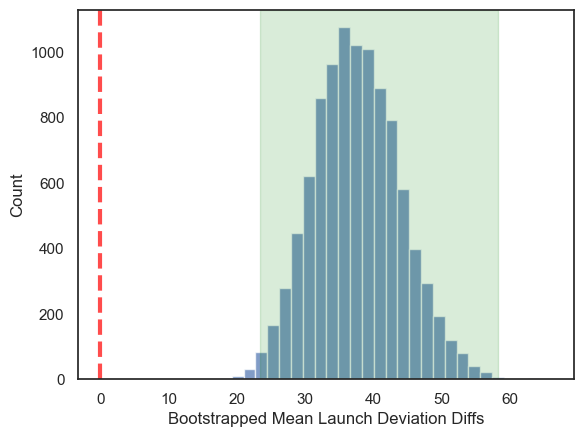

comparing washout to baseline | experiment = -2.0 | target = L60 | trial = 203


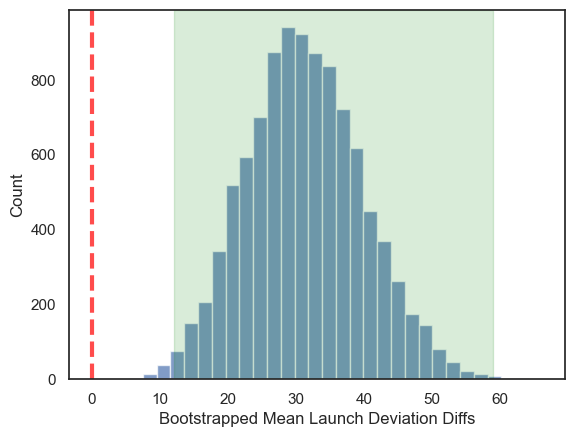

comparing washout to baseline | experiment = -3.0 | target = L60 | trial = 209


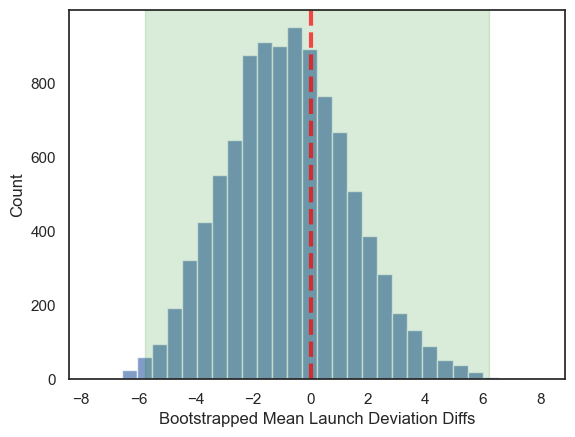

comparing washout to baseline | experiment = -2.0 | target = L60 | trial = 209


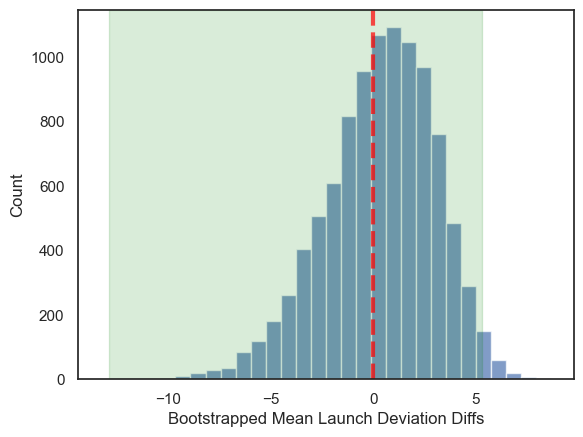

comparing washout to baseline | experiment = -3.0 | target = L30 | trial = 203


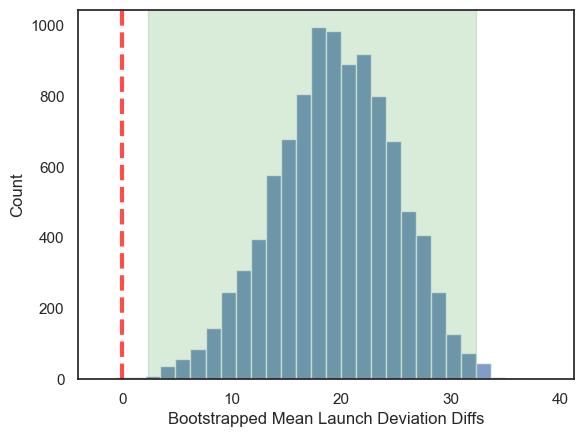

comparing washout to baseline | experiment = -2.0 | target = L30 | trial = 203


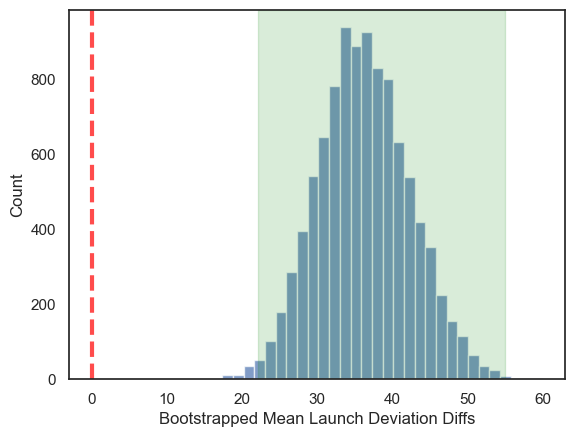

comparing washout to baseline | experiment = -3.0 | target = L30 | trial = 209


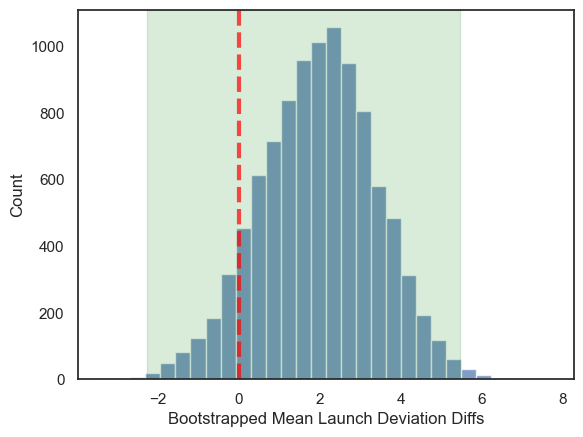

comparing washout to baseline | experiment = -2.0 | target = L30 | trial = 209


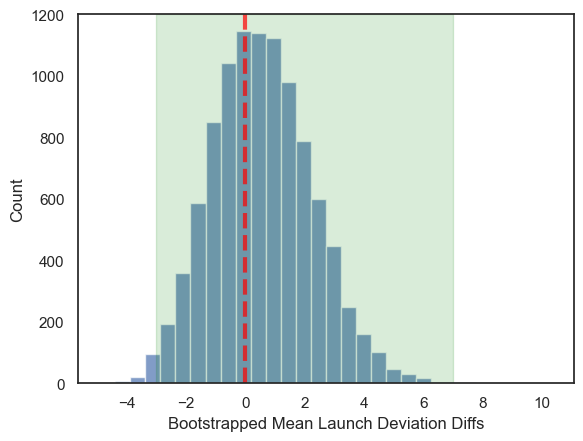

comparing washout to baseline | experiment = -3.0 | target = R30 | trial = 203


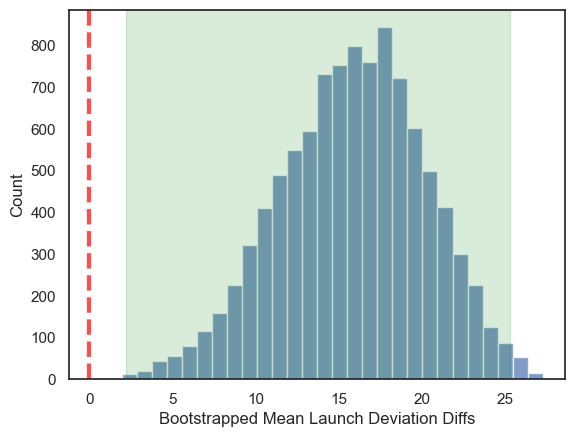

comparing washout to baseline | experiment = -2.0 | target = R30 | trial = 203


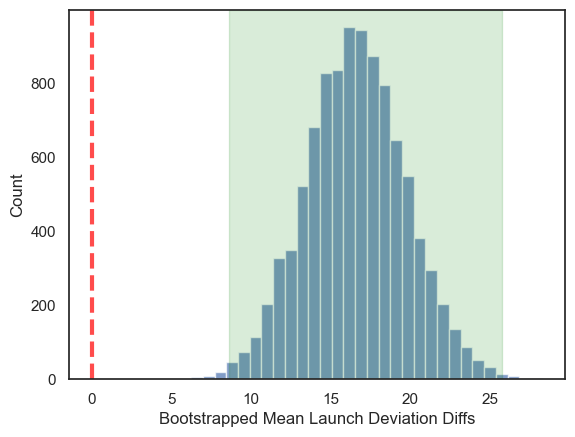

comparing washout to baseline | experiment = -3.0 | target = R30 | trial = 209


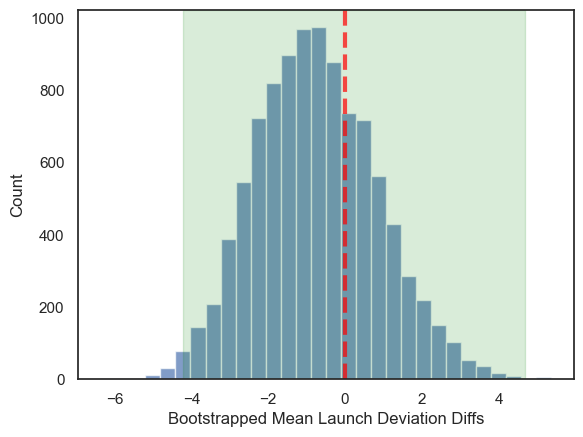

comparing washout to baseline | experiment = -2.0 | target = R30 | trial = 209


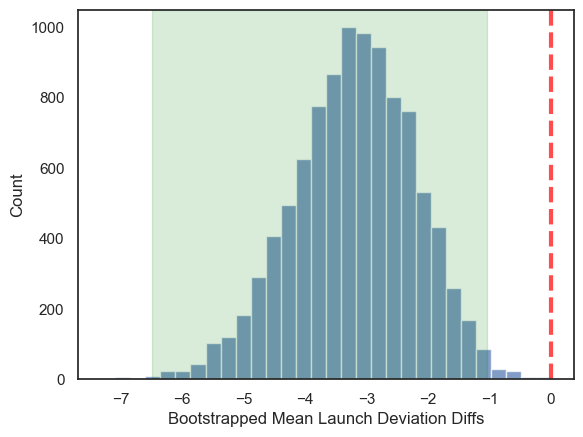

comparing washout to baseline | experiment = -3.0 | target = R60 | trial = 203


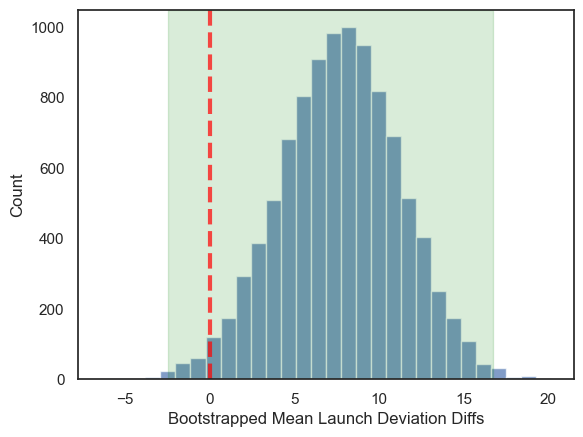

comparing washout to baseline | experiment = -2.0 | target = R60 | trial = 203


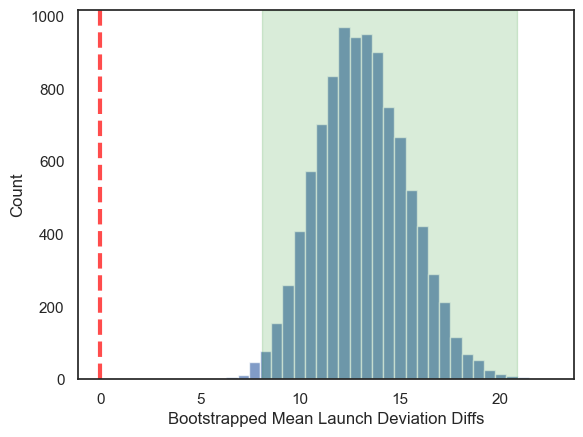

comparing washout to baseline | experiment = -3.0 | target = R60 | trial = 209


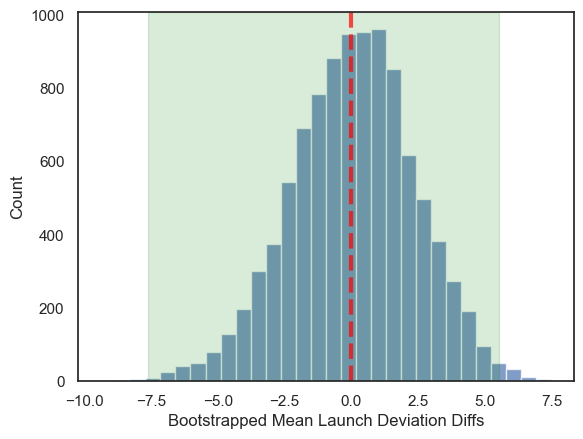

comparing washout to baseline | experiment = -2.0 | target = R60 | trial = 209


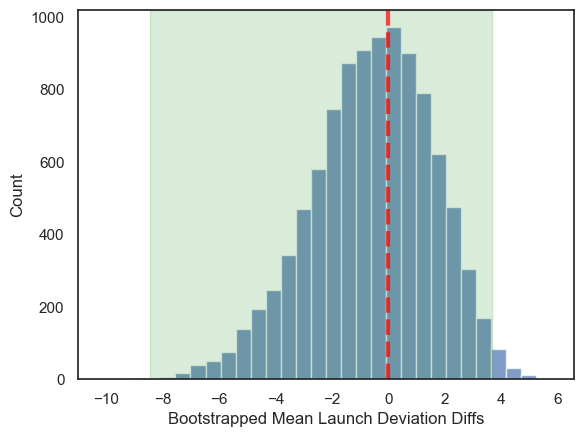

comparing washout to training_1 | experiment = -3.0 | target = L60 | trial = 203


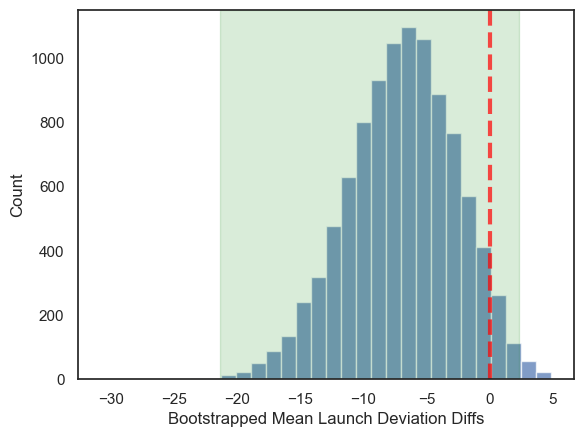

comparing washout to training_1 | experiment = -2.0 | target = L60 | trial = 203


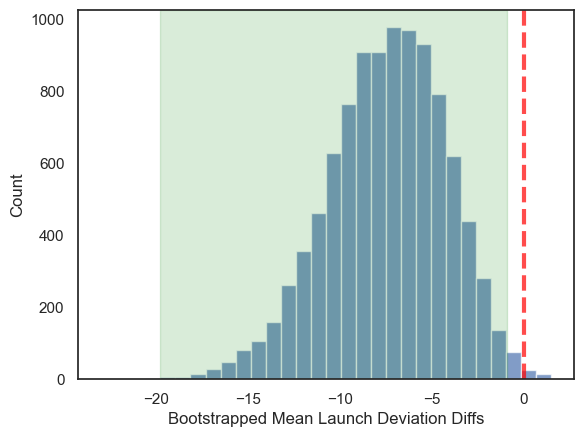

comparing washout to training_1 | experiment = -3.0 | target = L60 | trial = 209


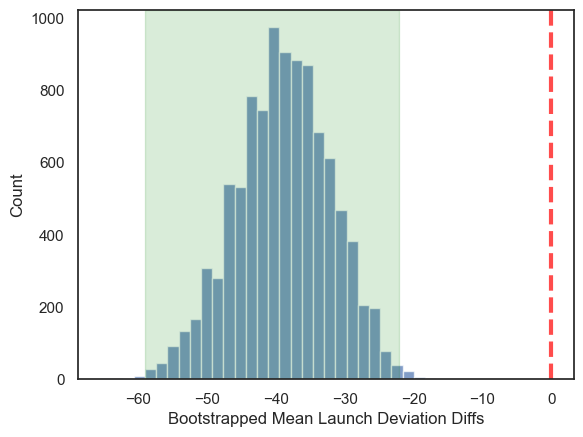

comparing washout to training_1 | experiment = -2.0 | target = L60 | trial = 209


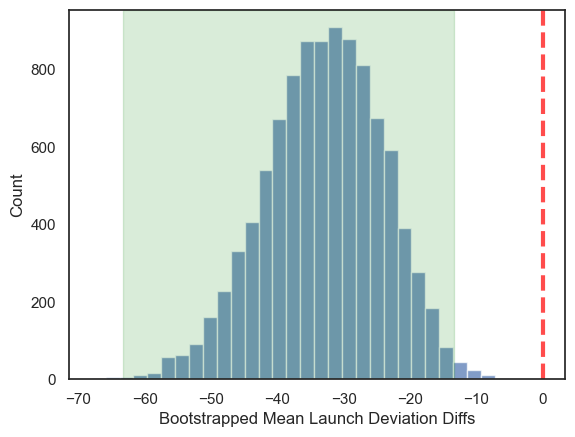

comparing washout to training_1 | experiment = -3.0 | target = L30 | trial = 203


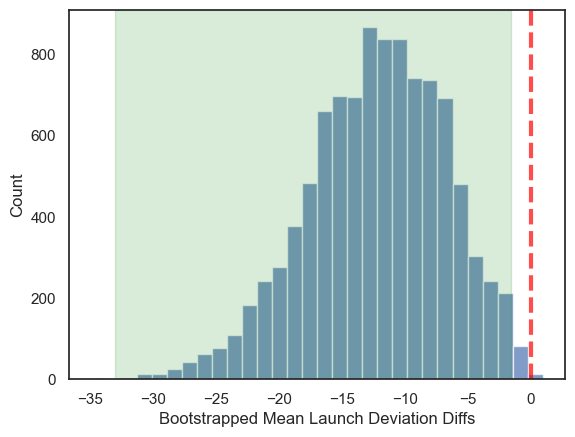

comparing washout to training_1 | experiment = -2.0 | target = L30 | trial = 203


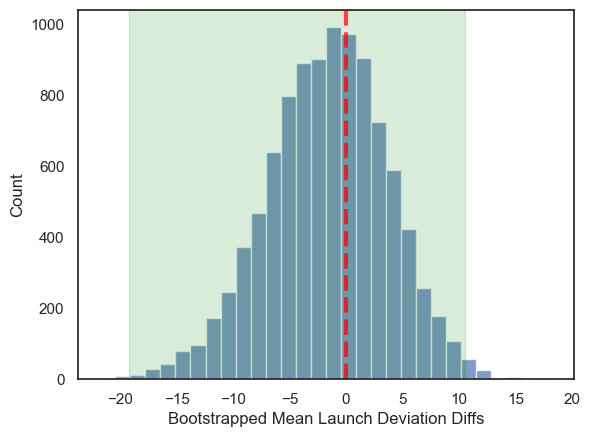

comparing washout to training_1 | experiment = -3.0 | target = L30 | trial = 209


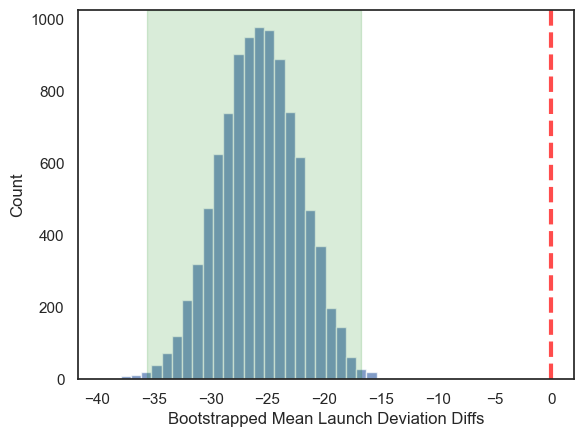

comparing washout to training_1 | experiment = -2.0 | target = L30 | trial = 209


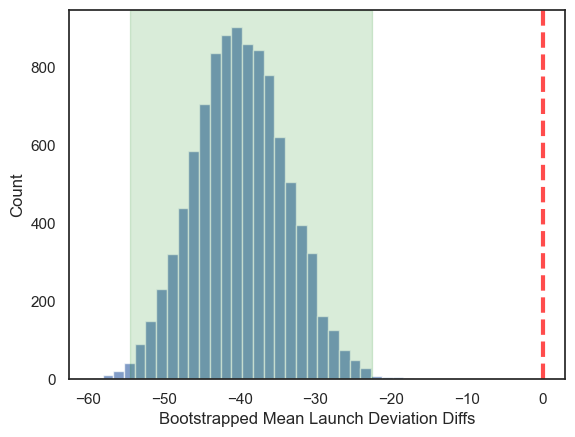

comparing washout to training_1 | experiment = -3.0 | target = R30 | trial = 203


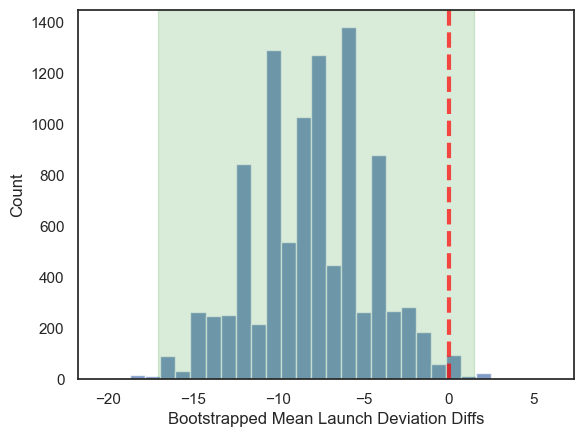

comparing washout to training_1 | experiment = -2.0 | target = R30 | trial = 203


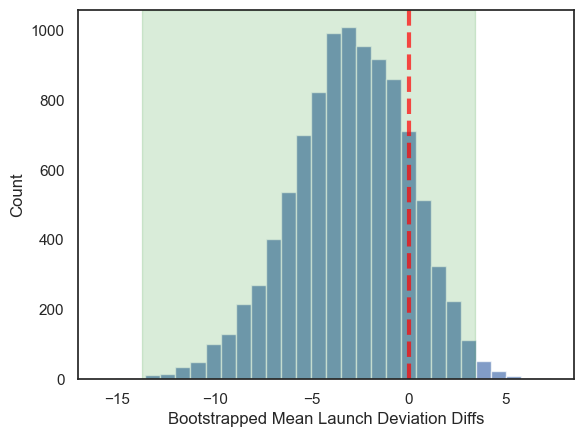

comparing washout to training_1 | experiment = -3.0 | target = R30 | trial = 209


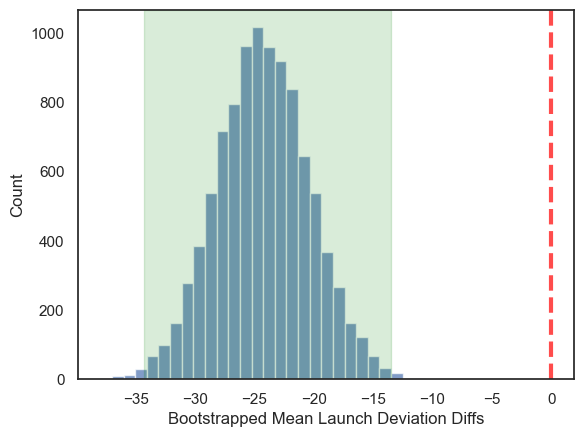

comparing washout to training_1 | experiment = -2.0 | target = R30 | trial = 209


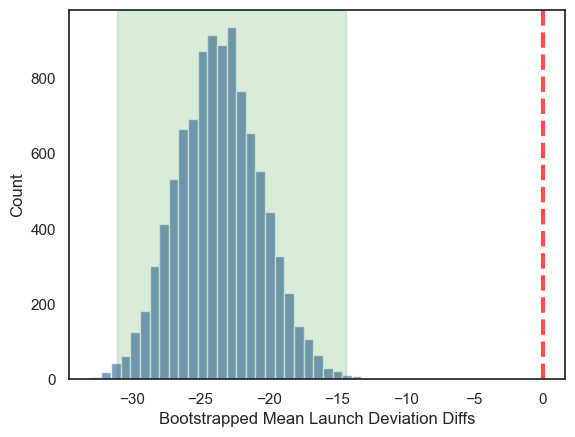

comparing washout to training_1 | experiment = -3.0 | target = R60 | trial = 203


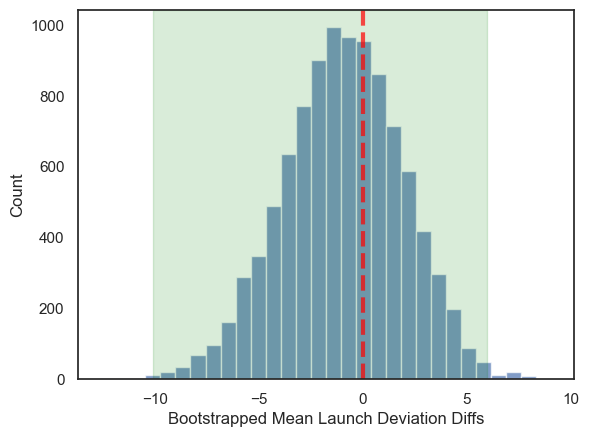

comparing washout to training_1 | experiment = -2.0 | target = R60 | trial = 203


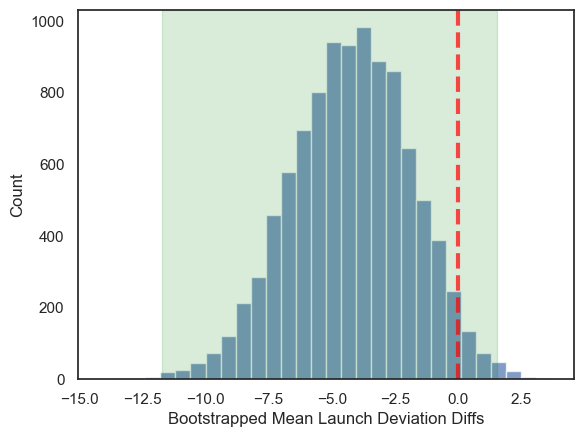

comparing washout to training_1 | experiment = -3.0 | target = R60 | trial = 209


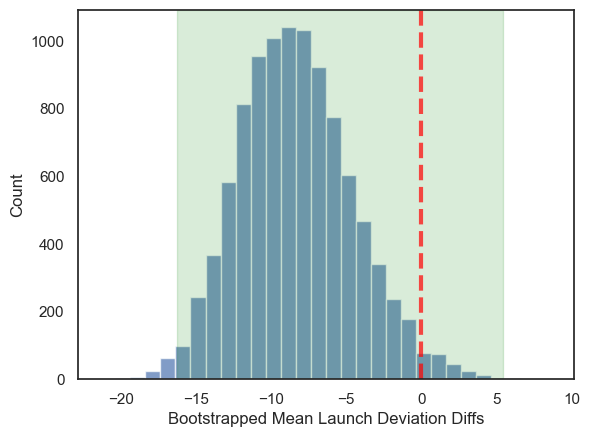

comparing washout to training_1 | experiment = -2.0 | target = R60 | trial = 209


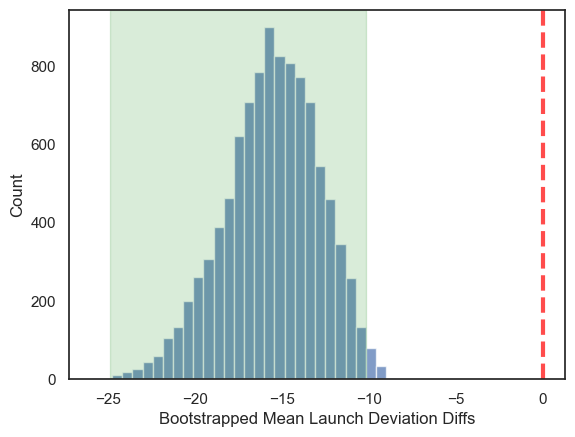

,water_speed,target,trial,mean_change_from_baseline,ci_low_baseline,ci_high_baseline,n_ppid_baseline,is_sig_from_baseline,mean_change_from_training_1,ci_low_training_1,ci_high_training_1,n_ppid_training_1,is_sig_from_training_1,block_num,trial_in_block
0,-3.0,L30,203,19.387656,2.351104,32.251654,8,True,-12.246086,-33.040622,-1.582598,8,False,1,1
1,-3.0,L30,204,2.039652,-5.498793,5.746678,16,False,-27.954768,-39.531574,-17.537835,17,False,1,2
2,-3.0,L30,205,2.740974,-1.413753,7.024587,9,False,-31.977507,-44.071550,-18.606584,10,False,1,3
3,-3.0,L30,206,3.018467,-1.112958,8.823578,15,False,-24.449992,-32.207973,-11.347810,15,False,1,4
4,-3.0,L30,207,4.855685,0.371375,9.501509,11,True,-25.233778,-41.188508,-14.475487,11,False,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,-2.0,R60,270,3.030081,-1.813184,11.715726,7,False,-13.506959,-20.550513,0.694857,7,False,5,4
316,-2.0,R60,271,-0.460952,-5.573792,4.239160,15,False,-18.088428,-23.835743,-11.478889,15,False,5,5
317,-2.0,R60,272,1.430157,-2.631538,9.166642,7,False,-13.599589,-23.648504,-1.896738,7,False,5,6
318,-2.0,R60,273,2.437045,-0.592837,5.804971,16,False,-13.734937,-19.324538,-8.117970,16,False,5,7


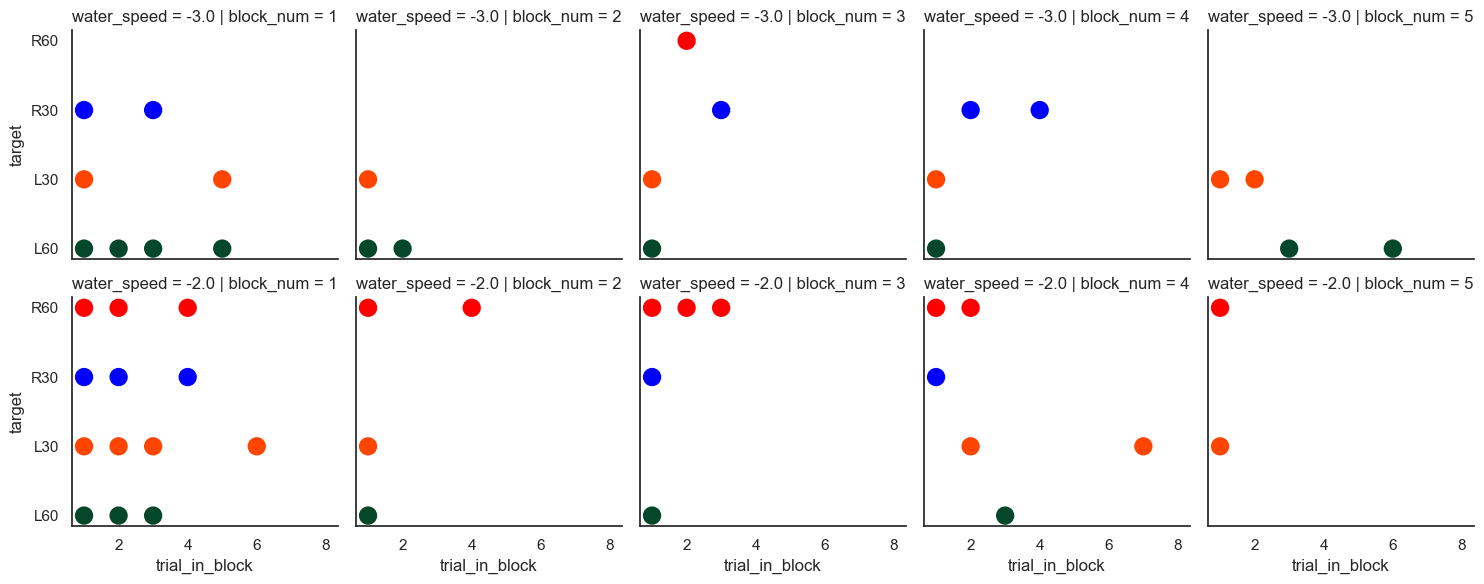

In [75]:
from src.bootstrap_new import run_bootstrap_new

# baseline vs washout 1
baseline_washout_1_diff_CIs = run_bootstrap_new(df_bc, 
              y_col='launch_deviation',
              ppid_col='ppid_full',
              trial_col='trial_num',
              phase_col='phase',
              target_col='target_x_label',
              water_state_col='water_speed_binary'
                               )  

# training 1 vs washout 1
training_1_washout_1_diff_CIs = run_bootstrap_new(df_bc, 
              y_col='launch_deviation',
              ppid_col='ppid_full',
              trial_col='trial_num',
              phase_col='phase',
              target_col='target_x_label',
              water_state_col='water_speed_binary',
              compare_phase_str='training_1'
                               )  

# merge new col into baseline_washout df
baseline_training_1_washout_1_df = pd.merge(
    baseline_washout_1_diff_CIs,
    training_1_washout_1_diff_CIs[['water_speed','target','trial','mean_change_from_training_1',
                                   'ci_low_training_1','ci_high_training_1','n_ppid_training_1','is_sig_from_training_1']],
    on=['water_speed','target','trial'],
    how='left'
    )    

# add block counter columns to merged df
baseline_training_1_washout_1_df['block_num'] = (baseline_training_1_washout_1_df.groupby(['target','water_speed']).cumcount() // 8) + 1
baseline_training_1_washout_1_df['trial_in_block'] = (baseline_training_1_washout_1_df.groupby(['target','water_speed']).cumcount() % 8) + 1 
# ensure target is categorical
baseline_training_1_washout_1_df['target'] = pd.Categorical(baseline_training_1_washout_1_df['target'], 
                                                            categories=['R60','R30','L30','L60'], ordered=True)

baseline_training_1_washout_1_df.to_csv(path_or_buf="C:/Users/jacob/downloads/baseline_training_1_washout_1_df.csv")

# print(baseline_training_1_washout_1_df.head(50))


from src.plotting import plot_aftereffects

plot_aftereffects(data = baseline_training_1_washout_1_df)

# show data: 
baseline_training_1_washout_1_df

Plot washout 1 and training 1 

,water_speed,target,trial,mean_change_from_baseline,ci_low_baseline,ci_high_baseline,n_ppid_baseline,is_sig_from_baseline,mean_change_from_training_2,ci_low_training_2,ci_high_training_2,n_ppid_training_2,is_sig_from_training_2,block_num,trial_in_block
200,-2.0,L60,425,6.185489,-0.197725,11.228075,8,False,-30.303285,-52.307445,-7.327031,8,False,1,1
201,-2.0,L60,426,4.469823,0.727583,9.874361,13,True,-29.880153,-52.687005,-13.529794,13,False,1,2
202,-2.0,L60,427,2.112169,-2.693314,7.624124,13,False,-38.636086,-58.411238,-19.426067,13,False,1,3
203,-2.0,L60,428,-0.268379,-2.787771,1.667393,7,False,-28.640363,-45.754767,-12.524197,8,False,1,4
204,-2.0,L60,429,1.273109,-0.692145,3.907492,11,False,-37.034216,-56.242934,-18.675173,12,False,1,5
205,-2.0,L60,430,2.745606,-4.112318,8.593621,9,False,-30.424092,-53.212691,-14.073880,9,False,1,6
206,-2.0,L60,431,-0.136434,-2.784312,4.390835,18,False,-34.000349,-51.513471,-20.262729,19,False,1,7
207,-2.0,L60,432,-5.589617,-13.857900,1.230400,3,False,-47.331676,-74.623100,-17.048332,3,False,1,8
208,-2.0,L60,441,3.524730,-4.032203,8.542782,10,False,-27.938823,-53.173809,-9.745533,10,False,2,1
209,-2.0,L60,442,2.735272,-3.598658,11.285366,11,False,-36.151840,-57.959810,-15.011018,12,False,2,2


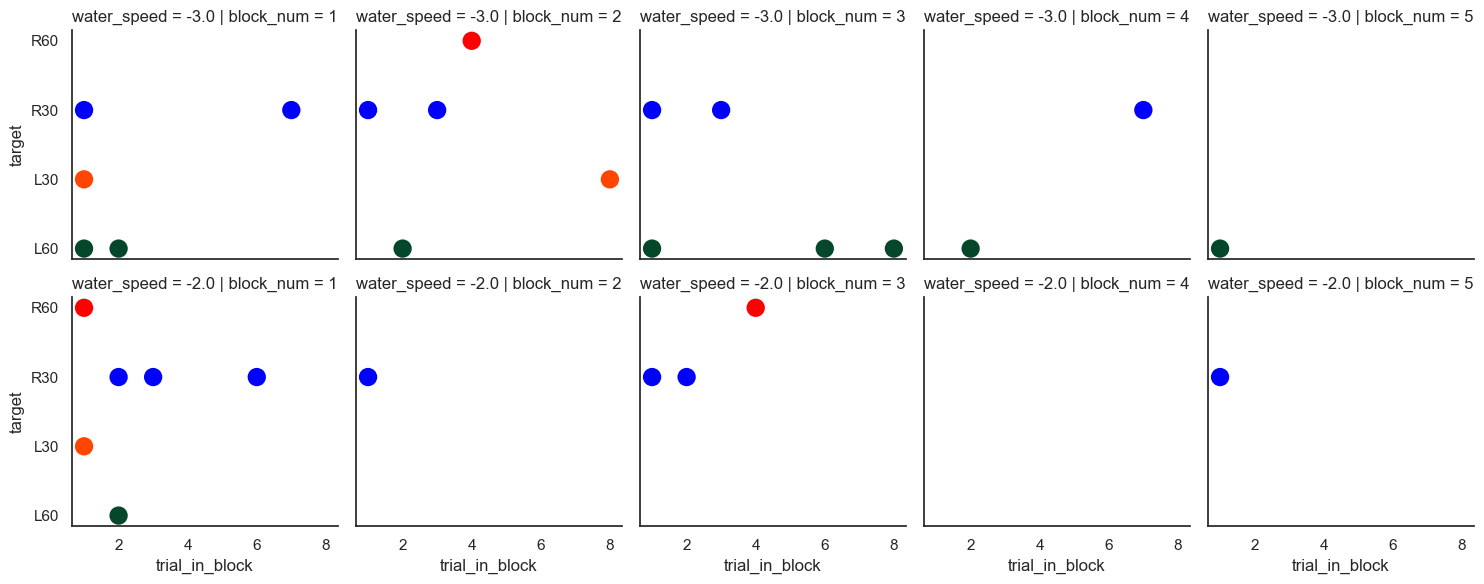

In [49]:
from src.bootstrap_new import run_bootstrap_new

# baseline vs washout 2
baseline_washout_2_diff_CIs = run_bootstrap_new(df_bc, 
              y_col='launch_deviation',
              ppid_col='ppid_full',
              trial_col='trial_num',
              phase_col='phase',
              target_col='target_x_label',
              water_state_col='water_speed_binary',
              washout_str='washout_2'
                               )  

# training 2 vs washout 2
training_2_washout_2_diff_CIs = run_bootstrap_new(df_bc, 
              y_col='launch_deviation',
              ppid_col='ppid_full',
              trial_col='trial_num',
              phase_col='phase',
              target_col='target_x_label',
              water_state_col='water_speed_binary',
              compare_phase_str='training_2',
              washout_str='washout_2'
                               )  

# merge new col into baseline_washout df
baseline_training_2_washout_2_df = pd.merge(
    baseline_washout_2_diff_CIs,
    training_2_washout_2_diff_CIs[['water_speed','target','trial','mean_change_from_training_2',
                                   'ci_low_training_2','ci_high_training_2','n_ppid_training_2','is_sig_from_training_2']],
    on=['water_speed','target','trial'],
    how='left'
    )    

# add block counter columns to merged df
baseline_training_2_washout_2_df['block_num'] = (baseline_training_2_washout_2_df.groupby(['target','water_speed']).cumcount() // 8) + 1
baseline_training_2_washout_2_df['trial_in_block'] = (baseline_training_2_washout_2_df.groupby(['target','water_speed']).cumcount() % 8) + 1 
# ensure target is categorical
baseline_training_2_washout_2_df['target'] = pd.Categorical(baseline_training_1_washout_1_df['target'], 
                                                            categories=['R60','R30','L30','L60'], ordered=True)

baseline_training_2_washout_2_df.to_csv(path_or_buf="C:/Users/jacob/downloads/baseline_training_2_washout_2_df.csv")

baseline_training_2_washout_2_df.head(50)


from src.plotting import plot_aftereffects

plot_aftereffects(data = baseline_training_2_washout_2_df,
                  marker_variable_list = ['is_sig_from_baseline','is_sig_from_training_2'],)

baseline_training_2_washout_2_df[
    (baseline_training_2_washout_2_df['target'] == 'L60') & 
    (baseline_training_2_washout_2_df['water_speed'] == -2.0)
].head(50)

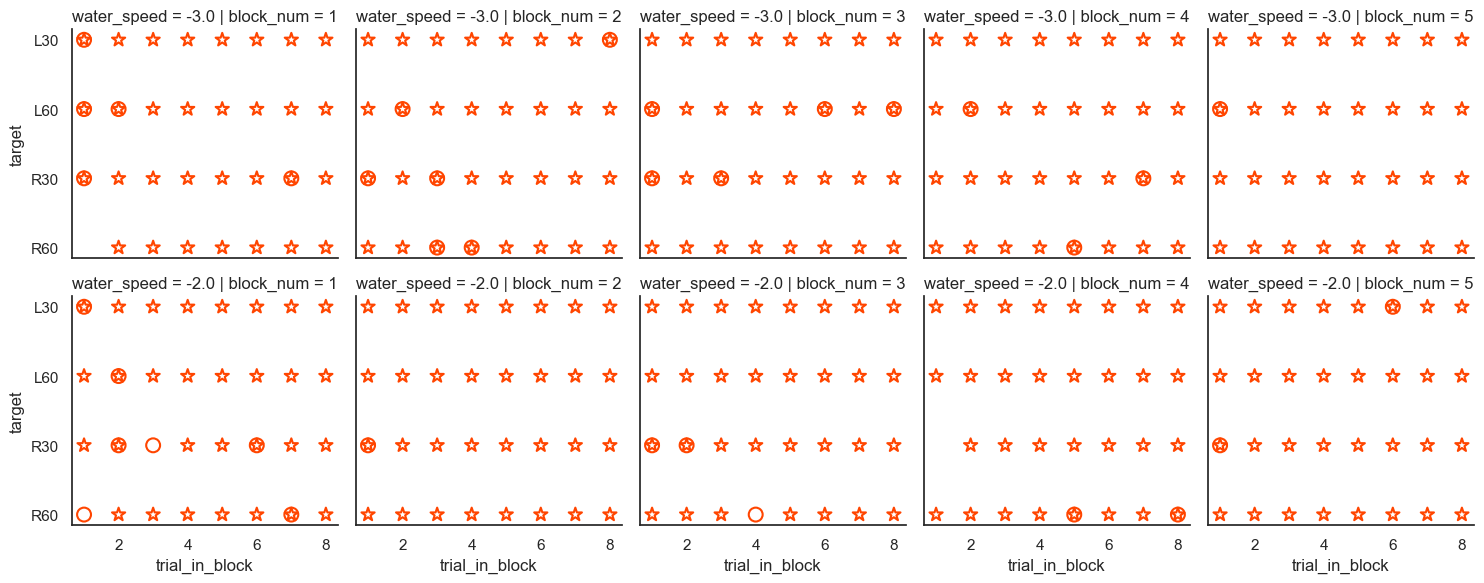

In [59]:
from src.bootstrap_new import run_bootstrap_new


training_2_washout_2_diff_CIs = run_bootstrap_new(df_bc, 
              y_col='launch_deviation',
              ppid_col='ppid_full',
              trial_col='trial_num',
              phase_col='phase',
              target_col='target_x_label',
              water_state_col='water_speed_binary',
              compare_phase_str='training_2',
              washout_str='washout_2'
                               )  
training_2_washout_2_diff_CIs.head(50)

# merge new col into baseline_washout df
merged_df = pd.merge(
    baseline_washout_2_diff_CIs,
    training_2_washout_2_diff_CIs[['water_speed','target','trial','mean_change_from_training_2',
                                   'ci_low_training_2','ci_high_training_2','n_ppid_training_2','is_sig_training_2_AE']],
    on=['water_speed','target','trial'],
    how='left'
    )    

# add block counter columns to merged df
merged_df['block_num'] = (merged_df.groupby(['target','water_speed']).cumcount() // 8) + 1
merged_df['trial_in_block'] = (merged_df.groupby(['target','water_speed']).cumcount() % 8) + 1 


from src.plotting import plot_aftereffects
plot_aftereffects(data = merged_df,
                  marker_variable_list = ['is_sig_baseline_AE','is_sig_training_2_AE'],)

In [187]:

# per_targets_CIs = run_bootstrap_old(df_baseline_last8, 
#               y_col=['launch_deviation_mean_bc'],
#               group_cols=['target_x_label','trial_num','speed_label']
#                                )

# print("\n\n CI High \n\n", per_targets_CIs.groupby(['target_x_label','speed_label'])['ci_high'].mean())
# print("\n\n CI Low \n\n", per_targets_CIs.groupby(['target_x_label','speed_label'])['ci_low'].mean())

# print("\n\n mean \n\n", per_targets_CIs.groupby(['target_x_label','speed_label'])['mean'].mean())

                launch_deviation_mean_bc
target_x_label                          
L60                                  160
L30                                  164
R30                                  172
R60                                  170
                launch_deviation_mean_bc
target_x_label                          
L60                             3.975987
L30                             4.329516
R30                             3.853744
R60                             4.221483


 CI High 

 target_x_label  speed_label
L30             -3.0           [2.9323790765237074]
                -2.0           [2.9641280368254894]
L60             -3.0           [2.2161946033707656]
                -2.0           [3.2407286259165335]
R30             -3.0           [2.3698228976907196]
                -2.0           [2.7202410357995155]
R60             -3.0           [2.6286557863863127]
                -2.0              [2.7300579286651]
Name: ci_high, dtype: object


 CI Low 

 target_x

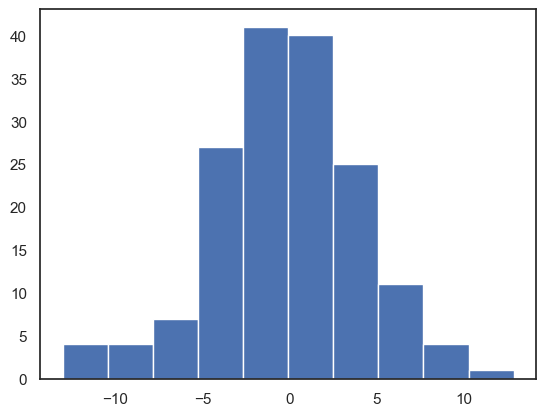

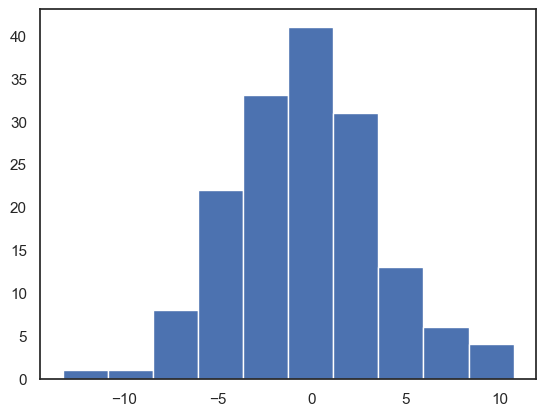

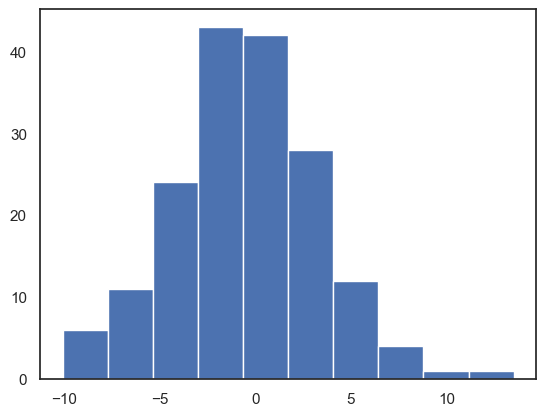

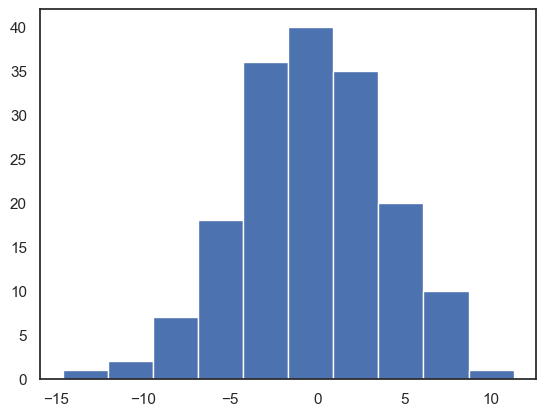

In [237]:

for t in np.unique(df_baseline_last8['target_x_label']):

    df_subset = df_baseline_last8[df_baseline_last8['target_x_label'] == t]
    
    plt.hist(df_subset['launch_deviation_mean_bc'])
    plt.show()
    

In [239]:
from src.bootstrap import calculate_distribution_bounds



per_target_bounds = calculate_distribution_bounds(df_baseline_last8, 
              y_col=['launch_deviation_mean_bc'],
              ppid_col = ['ppid_full'],
              group_cols=['target_x_label','speed_label'])


per_target_bounds
                               
print("\n\n sigma High \n\n", per_target_bounds.groupby(['target_x_label','speed_label'])['sigma_high'].mean())
print("\n\n sigma Low \n\n", per_target_bounds.groupby(['target_x_label','speed_label'])['sigma_low'].mean())

print("\n\n mean \n\n", per_target_bounds.groupby(['target_x_label','speed_label'])['mean'].mean())



 sigma High 

 target_x_label  speed_label
L30             -3.0           5.075685
                -2.0           5.202060
L60             -3.0           5.538893
                -2.0           5.602057
R30             -3.0           4.821839
                -2.0           5.898116
R60             -3.0           5.775427
                -2.0           5.000671
Name: sigma_high, dtype: float64


 sigma Low 

 target_x_label  speed_label
L30             -3.0          -5.118974
                -2.0          -5.953653
L60             -3.0          -7.175761
                -2.0          -5.638596
R30             -3.0          -5.696298
                -2.0          -6.578527
R60             -3.0          -6.303210
                -2.0          -6.109518
Name: sigma_low, dtype: float64


 mean 

 target_x_label  speed_label
L30             -3.0          -0.021645
                -2.0          -0.375796
L60             -3.0          -0.818434
                -2.0          -0.018269
R30    

[autoreload of src.bootstrap failed: Traceback (most recent call last):
  File "C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\IPython\extensions\autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\IPython\extensions\autoreload.py", line 475, in superreload
    module = reload(module)
  File "C:\Users\jacob\anaconda3\envs\water_current_project\lib\importlib\__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 619, in _exec
  File "<frozen importlib._bootstrap_external>", line 879, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1017, in get_code
  File "<frozen importlib._bootstrap_external>", line 947, in source_to_code
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "C:\Users\jacob\water_current_MA\src\bootstrap.py", line 171
    ave
    ^

Final 8 training CI

In [41]:
from src.bootstrap import run_bootstrap

df_t1 = df_bc[df_bc['phase'] == 'training_1']
max_trials = df_t1['trial_num'].max()

# grab last 8 trials of t1 
df_t1_last8 = df_t1[df_t1['trial_num'] >= max_trials - 8]
#print(df_baseline_last8['trial_num'].min())


# from src.bootstrap import run_bootstrap

# all_targets_CIs = run_bootstrap(df_t1_last8, 
#               y_col=['launch_deviation']
#                        )
# print("ALL targets:\n\n", all_targets_CIs)

per_targets_CIs = run_bootstrap(df_t1_last8, 
              y_col=['launch_deviation_mean_bc'],
              group_cols=['target_x_label','speed_label','trial_num']
                               )
                               
print("\n\n CI High \n\n", per_targets_CIs.groupby(['target_x_label','speed_label'])['ci_high'].mean())
print("\n\n CI Low \n\n", per_targets_CIs.groupby(['target_x_label','speed_label'])['ci_low'].mean())

print("\n\n mean \n\n", per_targets_CIs.groupby(['target_x_label','speed_label'])['mean'].mean())



 CI High 

 target_x_label  speed_label
L30             -3.0           [40.108427046344104]
                -2.0            [52.72843977135484]
L60             -3.0            [57.33530894953997]
                -2.0            [59.70507832697466]
R30             -3.0            [32.08323889784046]
                -2.0           [30.106922225052628]
R60             -3.0            [16.75460886392563]
                -2.0           [23.125427152019046]
Name: ci_high, dtype: object


 CI Low 

 target_x_label  speed_label
L30             -3.0            [18.991865546731212]
                -2.0            [18.204815013672462]
L60             -3.0            [28.292200306844663]
                -2.0            [22.658500770972623]
R30             -3.0            [10.209869491747206]
                -2.0             [11.85253300927284]
R60             -3.0           [-0.9412564989894483]
                -2.0             [9.693653802803516]
Name: ci_low, dtype: object


 mean 

 target_x_

In [43]:
from src.bootstrap import calculate_distribution_bounds



per_target_bounds = calculate_distribution_bounds(df_t1_last8, 
              y_col=['launch_deviation_mean_bc'],
              group_cols=['target_x_label','speed_label','trial_num'])



                               
print("\n\n sigma High \n\n", per_target_bounds.groupby(['target_x_label','speed_label'])['sigma_high'].mean())
print("\n\n sigma Low \n\n", per_target_bounds.groupby(['target_x_label','speed_label'])['sigma_low'].mean())

print("\n\n mean \n\n", per_target_bounds.groupby(['target_x_label','speed_label'])['mean'].mean())



 sigma High 

 target_x_label  speed_label
L30             -3.0            67.988984
                -2.0            94.765993
L60             -3.0            89.226109
                -2.0           103.275861
R30             -3.0            58.027347
                -2.0            52.323210
R60             -3.0            40.392613
                -2.0            40.305649
Name: sigma_high, dtype: float64


 sigma Low 

 target_x_label  speed_label
L30             -3.0           -8.898345
                -2.0          -24.281773
L60             -3.0           -4.821378
                -2.0          -22.063131
R30             -3.0          -14.999294
                -2.0          -10.182018
R60             -3.0          -24.528455
                -2.0           -7.356400
Name: sigma_low, dtype: float64


 mean 

 target_x_label  speed_label
L30             -3.0           29.545319
                -2.0           35.242110
L60             -3.0           42.202365
                -2.0

L30


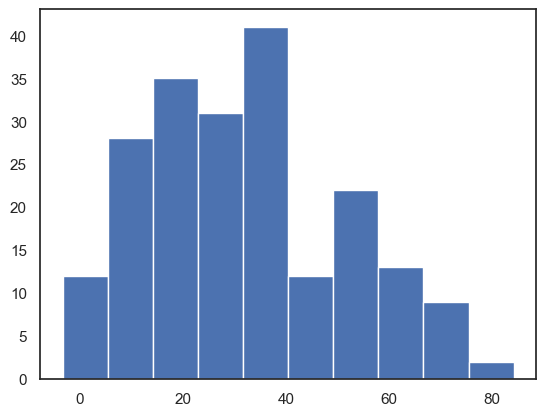

L60


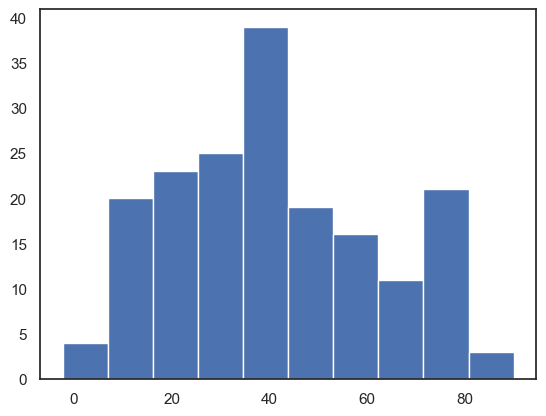

R30


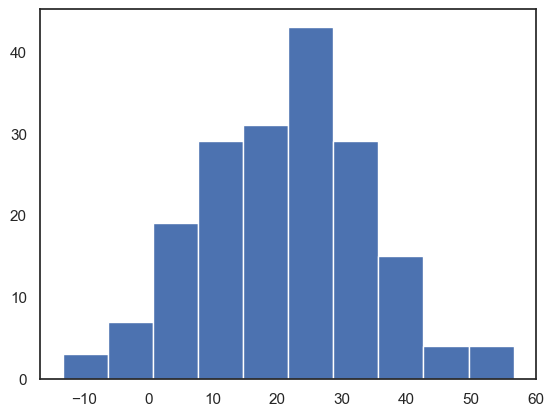

R60


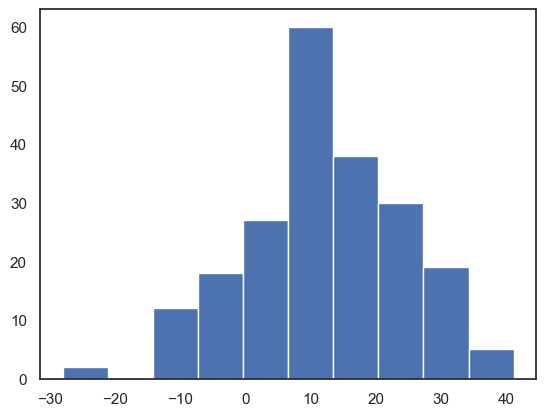

In [53]:

for t in np.unique(df_t1_last8['target_x_label']):
    print(t)
    df_subset = df_t1_last8[df_t1_last8['target_x_label'] == t]
    
    plt.hist(df_subset['launch_deviation_mean_bc'])
    plt.show()
    

hit min None
hit max None


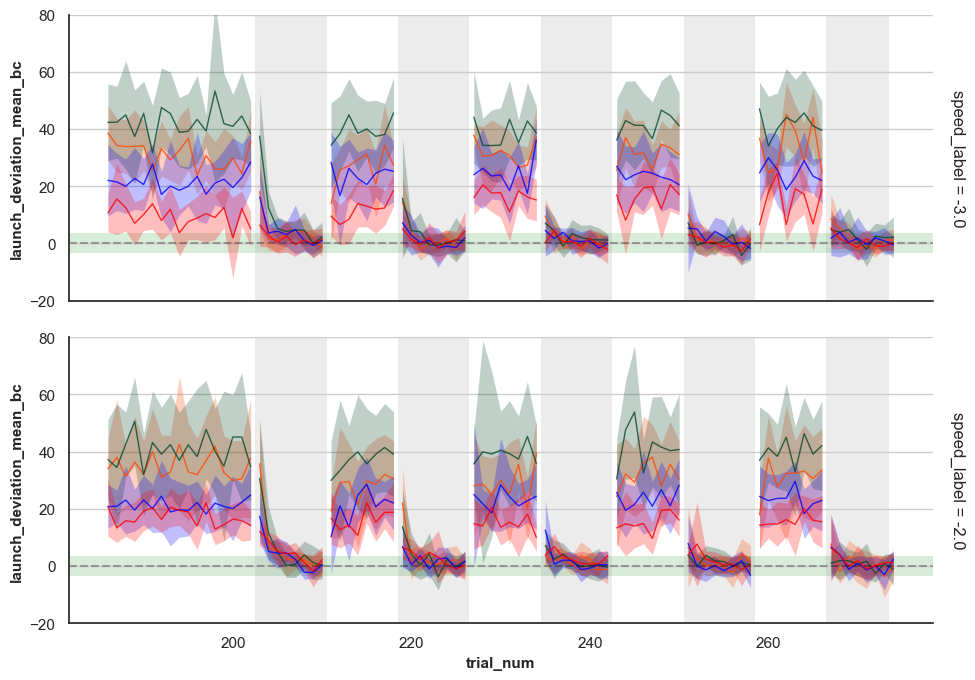

In [27]:
#


from src.plotting import plot_all_trials
plot_all_trials(df_c, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_deviation_mean_bc', # launch_deviation_mean_bc
                     x_col='trial_num',                
                     vertical_list=[],
                     hit_col='target_hit',
                     ref_range_col=None,
                     show_manual_span=True,
                     manual_span=np.array([-3.5,3.5]),
                     no_connect_col=['phase','water_speed_binary'],
                     context='notebook', 
                     transition_col='water_speed_binary', 
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-20,80),
                     show_zero_line=True
                    )         

hit min None
hit max None


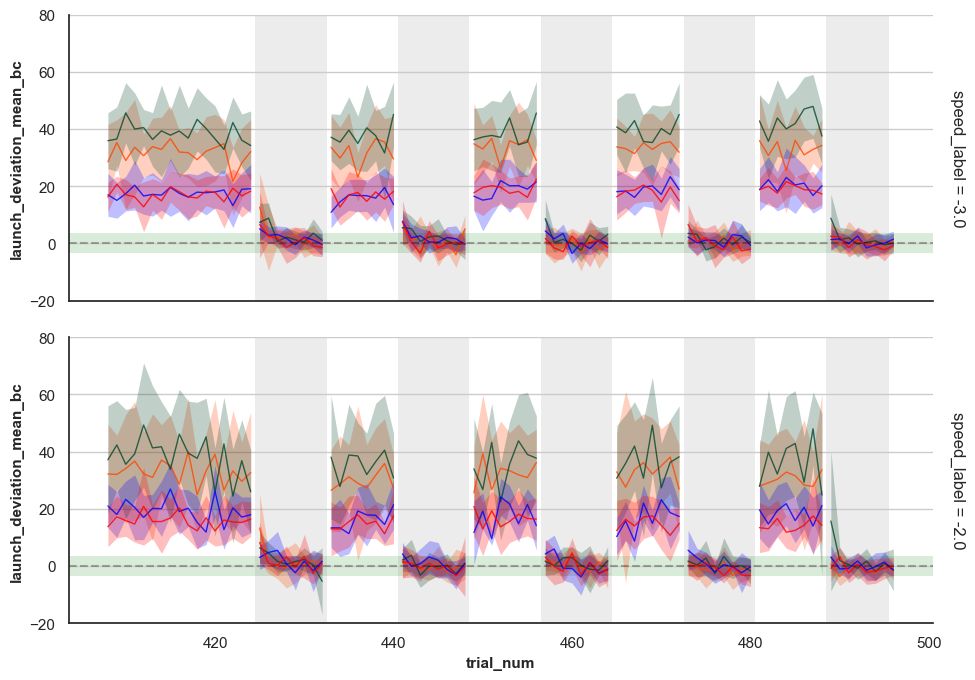

In [37]:
df_t2 = df_bc[df_bc['phase'] == 'training_2']
max_trials = df_t2['trial_num'].max()
# grab last 16 trials of t2 
df_t2_last16 = df_t2[df_t2['trial_num'] >= max_trials - 16]

df_c2 = pd.concat([df_t2_last16, df_w2]) # df_w2_early



from src.plotting import plot_all_trials
plot_all_trials(df_c2, 
                     col_col =None,
                     row_col='speed_label',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'launch_deviation_mean_bc', # launch_deviation_mean_bc
                     x_col='trial_num',                
                     vertical_list=[],
                     hit_col='target_hit',
                     ref_range_col=None,
                     show_manual_span=True,
                     manual_span=np.array([-3.5,3.5]),
                     no_connect_col=['phase','water_speed_binary'],
                     context='notebook', 
                     transition_col='water_speed_binary', 
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-20,80),
                     show_zero_line=True
                    )         

first trial

washout 1

In [40]:

# label key transition trials of interest (start trial of block)
trials = np.array([1, 9, 17, 25, 33])

# mask to check 
# df_w1['keep_trial'] = df_w1['phase_target_trial_num'].isin(trials)

# drop false 'keep_trial' rows
# df_w1_kept = df_w1[df_w1['keep_trial'] == True]





test = df_w1.groupby(['trial_num','target_x_label','water_speed_m_s','speed_label'])['launch_deviation_mean_bc'].mean()

file_path_t = f"..\\data\\dual_generalization\\test.csv"

test.to_csv(file_path_t, index=True)



# from src.plotting import plot_slopes
# plot_slopes(df_w1_kept,
#                          x_col='phase_target_trial_num',
#                          y_col='launch_deviation_mean_bc',
#                          hue_var='target_x_label', 
#                          ref_range_col='launch_deviation',
#                          facet_col='target_x_label',
#                          facet_row= 'speed_label',
#                          y_lim = (-50,25)
#                             )



C:\Users\jacob\AppData\Local\Temp\ipykernel_5976\3420907272.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test = df_w1.groupby(['trial_num','target_x_label','water_speed_m_s','speed_label'])['launch_deviation_mean_bc'].mean()


In [29]:
df_w1 = df_bc[df_bc['phase'] == 'washout_1'].copy()

washout_1 = df_w1.groupby(['trial_num','target_x_label','water_speed_m_s','speed_label'])['launch_deviation_mean_bc'].mean()

file_path_w1 = f"..\\data\\dual_generalization\\washout_1.csv"

washout_1.to_csv(file_path_w1, index=True)

C:\Users\jacob\AppData\Local\Temp\ipykernel_22464\1423124927.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  washout_1 = df_w1.groupby(['trial_num','target_x_label','water_speed_m_s','speed_label'])['launch_deviation_mean_bc'].mean()


In [7]:
df_w2 = df_bc[df_bc['phase'] == 'washout_2'].copy()

washout_2 = df_w2.groupby(['trial_num','target_x_label','water_speed_m_s','speed_label'])['launch_deviation_mean_bc'].mean()

file_path_w2 = f"..\\data\\dual_generalization\\washout_2.csv"

washout_2.to_csv(file_path_w2, index=True)

NameError: name 'df_bc' is not defined

In [5]:
def solve_target_angle_span(
    target_vx = np.array([-60.0, -30.0, 30.0, 60.0]),
    target_vz = np.array([140.0, 140.0, 140.0, 140.0]),
    ball_diameter = 10.0,
    target_diameter = 7.5
):
    effective_diameter = ball_diameter + target_diameter

    # distance from origin to target centre
    distance = np.sqrt(target_vx**2 + target_vz**2)

    # solve for angular diameter:
    angular_diameter_deg = np.degrees(2*np.arctan(effective_diameter/(2*distance)))

    return angular_diameter_deg
    

    
solve_target_angle_span()

array([6.57566426, 6.99429527, 6.99429527, 6.57566426])

first trial + 1

Early (first 2 trials, black) vs Late (Last 2 trials, red) of *Training Phase 1 (T1)*

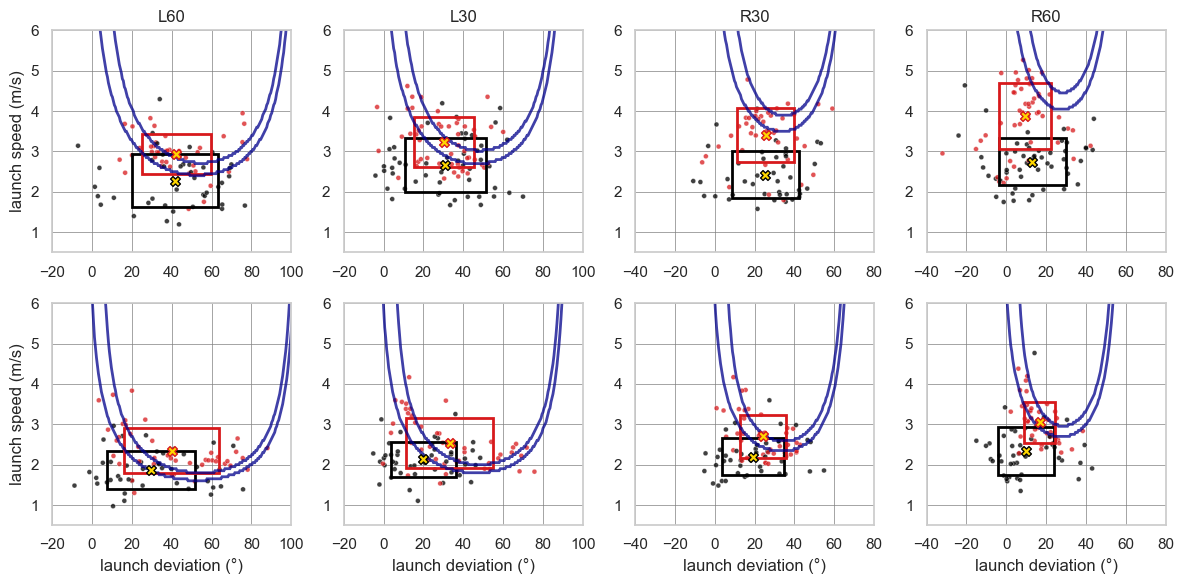

In [101]:
from src.plotting import plot_solution_space_heatmap

early_late_phase_df_2_t1_early = early_late_phase_df_2_t1[early_late_phase_df_2_t1['trial_set'] == 'early']


plot_solution_space_heatmap(early_late_phase_df_2_t1,
                            x_col='launch_deviation',
                            y_col='launch_Speed',
                            water_col='water_speed_m_s',
                            target_col='target_x_label',
                            colour_col='trial_set',
                            show_centre_sd=True
                           
                           )

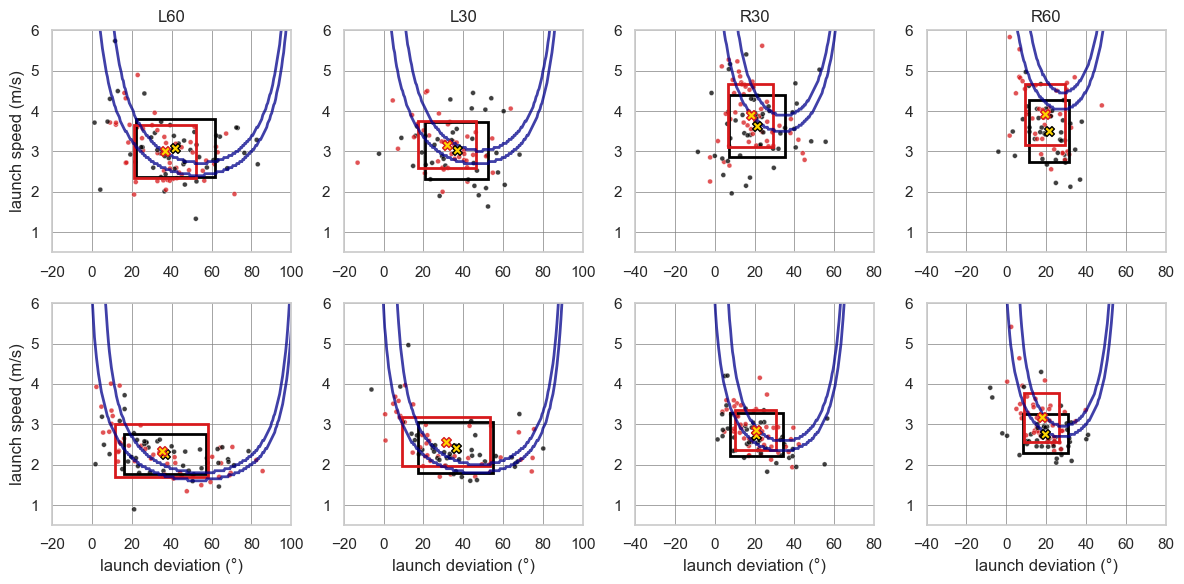

In [40]:
from src.plotting import plot_solution_space_heatmap

# early_late_phase_df_2_t2_early = early_late_phase_df_2_t2[early_late_phase_df_2_t2['trial_set'] == 'early']

plot_solution_space_heatmap(early_late_phase_df_2_t2,
                            x_col='launch_deviation',
                            y_col='launch_Speed',
                            water_col='water_speed_m_s',
                            target_col='target_x_label',
                            colour_col='trial_set',
                            show_centre_sd=True
                           
                           )